<a href="https://colab.research.google.com/github/8946-art/Boosting_eVISA_Business-Application/blob/main/NBFC%20Loan%20Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **NBFC Loan Default**

## **by Brian Kwame Renner Sadiku**



* Contents
* Overview of Dataset
* Exploratory Data Analysis
* Data Preparation
* Model Building
* Cross Validation Scores
* XGBoost Classifier
* Bagging Classifier
* Decision Tree Classifier
* Stacking Classifier
* Test Set Prediction


## **Background**

A non-banking financial institution (NBFI) or non-bank financial company (NBFC) is a Financial Institution that does not have a full banking license or is not supervised by a national or international banking regulatory agency. NBFC facilitates bank-related financial services, such as investment, risk pooling, contractual savings, and market brokering. The following is the story of a challenge faced by DHDL Ltd. (Name Changed), an NBFC in India. In recent times, the company is struggling to mark profits due to an increase in Loan Defaults. The company aims to determine the relative importance of each parameter with regards to their contribution as to whether a loan is going to default or not. Provided is a sample that contains the data of 90,000 + clients who have taken a loan from the company in the past with the information on whether the loan defaulted.

## **Objective**

The objective of this exercise is to understand which parameters play an important role in determining whether a client will default on the loan payment.

## **Data Dictionary**


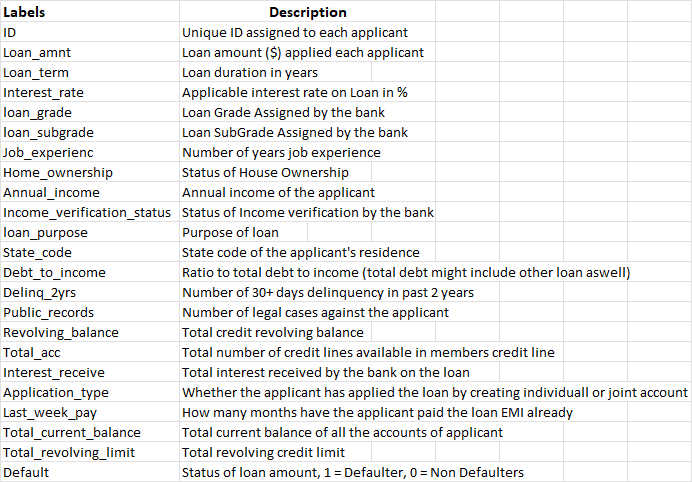


## **Overview of Dataset**

## Import Libraries

In [10]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# to suppress scientific notations
pd.set_option('display.float_format', lambda x: '%.3f' % x)
%matplotlib inline
sns.set()

## **Load dataset**

In [11]:
data = pd.read_csv('/content/Train_set..csv')
df = data.copy()

In [12]:
df.shape

(93174, 23)

In [13]:
pd.concat([df.head(5), df.sample(5), df.tail(5)])

,ID,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
0,72199369,9000,3 years,9.170,B,B2,<5 Years,OWN,85000.000,Not Verified,...,0.000,0.000,39519,20.000,59.600,INDIVIDUAL,4.000,95493.000,84100.000,0
1,14257956,18000,3 years,13.650,C,C1,<5 Years,OWN,64000.000,Verified,...,0.000,1.000,9783,24.000,3348.250,INDIVIDUAL,95.000,185433.000,13500.000,0
2,66216451,16000,3 years,7.260,A,A4,<5 Years,MORTGAGE,150000.000,Source Verified,...,2.000,0.000,13641,27.000,276.690,INDIVIDUAL,13.000,180519.000,19300.000,0
3,46974169,25000,3 years,13.990,C,C4,NaN,MORTGAGE,59800.000,Verified,...,0.000,0.000,35020,35.000,1106.720,INDIVIDUAL,17.000,183208.000,55400.000,0
4,46725961,17000,3 years,6.390,A,A2,10+ years,MORTGAGE,72000.000,Source Verified,...,0.000,0.000,23990,26.000,725.290,INDIVIDUAL,39.000,23990.000,81300.000,0
26957,49464320,15000,3 years,7.890,A,A5,10+ years,MORTGAGE,86000.000,Not Verified,...,0.000,0.000,21242,25.000,785.380,INDIVIDUAL,39.000,878217.000,27500.000,0
8770,57515336,10825,3 years,12.290,C,C1,<5 Years,RENT,56000.000,Not Verified,...,0.000,0.000,15370,23.000,611.450,INDIVIDUAL,26.000,49796.000,29100.000,0
72180,21688832,10000,5 years,20.990,E,E4,10+ years,MORTGAGE,57200.000,Not Verified,...,1.000,0.000,22926,23.000,3007.160,INDIVIDUAL,83.000,154344.000,27600.000,0
63326,11970320,11975,3 years,9.670,B,B1,6-10 years,RENT,35000.000,Not Verified,...,0.000,0.000,8117,32.000,1563.640,INDIVIDUAL,100.000,19926.000,34200.000,1
27547,59044426,7675,3 years,13.330,C,C3,<5 Years,MORTGAGE,33000.000,Source Verified,...,1.000,0.000,14527,37.000,129.570,INDIVIDUAL,9.000,137665.000,50300.000,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93174 entries, 0 to 93173
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          93174 non-null  int64  
 1   loan_amnt                   93174 non-null  int64  
 2   loan_term                   93174 non-null  object 
 3   interest_rate               93174 non-null  float64
 4   loan_grade                  93174 non-null  object 
 5   loan_subgrade               93174 non-null  object 
 6   job_experience              88472 non-null  object 
 7   home_ownership              93174 non-null  object 
 8   annual_income               93173 non-null  float64
 9   income_verification_status  93174 non-null  object 
 10  loan_purpose                93174 non-null  object 
 11  state_code                  93174 non-null  object 
 12  debt_to_income              93174 non-null  float64
 13  delinq_2yrs                 931

In [15]:
display(df.describe(include='all').T)
display(df.describe(include='float').T)
df.describe(include='object').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,93174.000,NaN,NaN,NaN,35050211.389,24149262.074,70735.000,10859832.500,37107507.000,58598949.500,73519746.000
loan_amnt,93174.000,NaN,NaN,NaN,14733.861,8428.185,500.000,8000.000,13000.000,20000.000,35000.000
loan_term,93174,2,3 years,65211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interest_rate,93174.000,NaN,NaN,NaN,13.233,4.369,5.320,9.990,12.990,16.200,28.990
loan_grade,93174,7,B,26865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_subgrade,93174,35,B4,5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_experience,88472,3,<5 Years,40610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,93174,5,MORTGAGE,46445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,93173.000,NaN,NaN,NaN,75028.259,69454.784,1200.000,45000.000,64000.000,90000.000,9500000.000
income_verification_status,93174,3,Source Verified,34487,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
interest_rate,93174.000,13.233,4.369,5.320,9.990,12.990,16.200,28.990
annual_income,93173.000,75028.259,69454.784,1200.000,45000.000,64000.000,90000.000,9500000.000
debt_to_income,93174.000,18.128,8.563,0.000,11.930,17.640,23.890,672.520
delinq_2yrs,93172.000,0.317,0.881,0.000,0.000,0.000,0.000,22.000
public_records,93172.000,0.196,0.581,0.000,0.000,0.000,0.000,49.000
total_acc,93172.000,25.249,11.855,1.000,17.000,24.000,32.000,119.000
interest_receive,93174.000,1747.264,2088.236,0.000,439.880,1070.755,2219.613,23172.310
last_week_pay,91250.000,58.155,44.327,0.000,22.000,48.000,83.000,291.000
total_current_balance,85788.000,139252.923,157686.791,0.000,29642.000,79363.500,207160.000,8000078.000
total_revolving_limit,85788.000,32085.903,47052.515,0.000,14000.000,23700.000,39700.000,9999999.000


,count,unique,top,freq
loan_term,93174,2,3 years,65211
loan_grade,93174,7,B,26865
loan_subgrade,93174,35,B4,5879
job_experience,88472,3,<5 Years,40610
home_ownership,93174,5,MORTGAGE,46445
income_verification_status,93174,3,Source Verified,34487
loan_purpose,93174,4,debt_consolidation,55241
state_code,93174,50,CA,13744
application_type,93174,2,INDIVIDUAL,93118


In [16]:
try:
    df.drop(['ID'], axis=1, inplace=True)
except:
    print("ID column already dropped")
df.columns

Index(['loan_amnt', 'loan_term', 'interest_rate', 'loan_grade',
       'loan_subgrade', 'job_experience', 'home_ownership', 'annual_income',
       'income_verification_status', 'loan_purpose', 'state_code',
       'debt_to_income', 'delinq_2yrs', 'public_records', 'revolving_balance',
       'total_acc', 'interest_receive', 'application_type', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit', 'default'],
      dtype='object')

In [17]:
df.isnull().sum().sort_values(ascending=False)

,0
total_revolving_limit,7386
total_current_balance,7386
job_experience,4702
last_week_pay,1924
delinq_2yrs,2
total_acc,2
public_records,2
annual_income,1
loan_subgrade,0
loan_term,0


In [18]:
df.isnull().sum()

,0
loan_amnt,0
loan_term,0
interest_rate,0
loan_grade,0
loan_subgrade,0
job_experience,4702
home_ownership,0
annual_income,1
income_verification_status,0
loan_purpose,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].astype('category')
df.select_dtypes(include='category').columns

Index(['loan_term', 'loan_grade', 'loan_subgrade', 'job_experience',
       'home_ownership', 'income_verification_status', 'loan_purpose',
       'state_code', 'application_type'],
      dtype='object')

In [21]:
for i in df.select_dtypes(include=['category']).columns:
    print('Unique values in', i, 'are :')
    print(df[i].value_counts(dropna=False))
    print('*'*50)

Unique values in loan_term are :
loan_term
3 years    65211
5 years    27963
Name: count, dtype: int64
**************************************************
Unique values in loan_grade are :
loan_grade
B    26865
C    25787
A    15534
D    14715
E     7378
F     2344
G      551
Name: count, dtype: int64
**************************************************
Unique values in loan_subgrade are :
loan_subgrade
B4    5879
B3    5879
C2    5479
C1    5443
C3    5270
C4    5182
B2    5169
B5    5095
B1    4843
A5    4723
C5    4413
D1    3716
A4    3631
D2    3239
D3    2759
D4    2717
A3    2450
A1    2377
A2    2353
D5    2284
E1    1924
E2    1736
E3    1513
E4    1228
E5     977
F1     745
F2     545
F3     465
F4     355
F5     234
G1     174
G2     146
G3     105
G5      66
G4      60
Name: count, dtype: int64
**************************************************
Unique values in job_experience are :
job_experience
<5 Years      40610
10+ years     30362
6-10 years    17500
NaN            4702
N

## Exploratory Data Analysis

## Univariate Analysis

In [22]:
def histogram_boxplot(feature, figsize=(15, 7), bins=None):
    """
    Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (15,10))
    bins: number of bins (default None / auto)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows = 2, # Number of rows of the subplot grid= 2
                                           sharex = True, # x-axis will be shared among all subplots
                                           gridspec_kw = {"height_ratios": (.25, .75)},
                                           figsize = figsize
                                           ) # creating the 2 subplots

    sns.boxplot(feature, ax=ax_box2, showmeans=True, color='yellow') # boxplot will be created and a star will indicate the mean value of the column
    sns.distplot(feature, kde=True, ax=ax_hist2, bins=bins) if bins else sns.distplot(feature, kde=True, ax=ax_hist2) # For histogram
    ax_hist2.axvline(np.mean(feature), color='green', linestyle='--') # Add mean to the histogram
    ax_hist2.axvline(np.median(feature), color='blue', linestyle='-');# Add median to the histogram

In [23]:
def perc_on_bar(feature):
    '''
    plot
    feature: categorical feature
    the function won't work if a column is passed in hue parameter
    '''
    #Creating a countplot for the feature
    sns.set(rc={'figure.figsize':(15,7)})
    ax=sns.countplot(x=feature, data=data, palette='mako')

    total = len(feature) # length of the column
    for p in ax.patches:
        # percentage of each class of the category
        percentage = 100 * p.get_height()/total
        percentage_label = f"{percentage:.1f}%"
        x = p.get_x() + p.get_width() / 2 - 0.05 # width of the plot
        y = p.get_y() + p.get_height()           # hieght of the plot
        ax.annotate(percentage_label, (x, y), size = 12) # annotate the percantage

    plt.show() # show the plot

In [24]:
### Function to plot distributions and Boxplots of customers
def target_plot(x, target='default'):
    '''
    plot
    feature: categorical feature
    the function won't work if a column is passed in hue parameter
    '''
    fig,axs = plt.subplots(2, 2, figsize=(12,10))
    axs[0, 0].set_title('Distribution of an default')
    sns.distplot(data[(data[target] == 1)][x], ax=axs[0,0], color='teal')
    axs[0, 1].set_title('Distribution of an non-default')
    sns.distplot(data[(data[target] == 0)][x], ax=axs[0,1], color='orange')

    axs[1,0].set_title('Boxplot w.r.t default')
    sns.boxplot(data[target],data[x], ax=axs[1,0],palette='gist_rainbow')
    axs[1,1].set_title('Boxplot w.r.t non-default - Without outliers')
    sns.boxplot(data[target],data[x],ax=axs[1,1],showfliers=False,palette='gist_rainbow')
    plt.tight_layout()
    plt.show()

In [25]:
df.select_dtypes(include='integer').columns

Index(['loan_amnt', 'revolving_balance', 'default'], dtype='object')

## loan_amnt

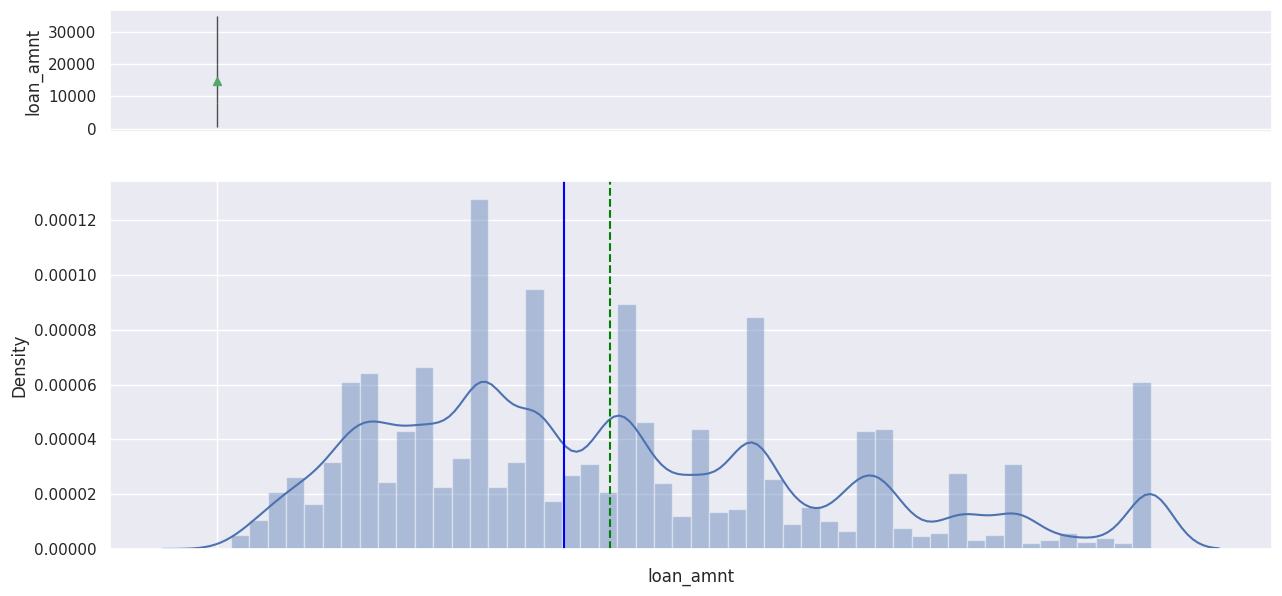

In [26]:
histogram_boxplot(df.loan_amnt)

## revolving_balance

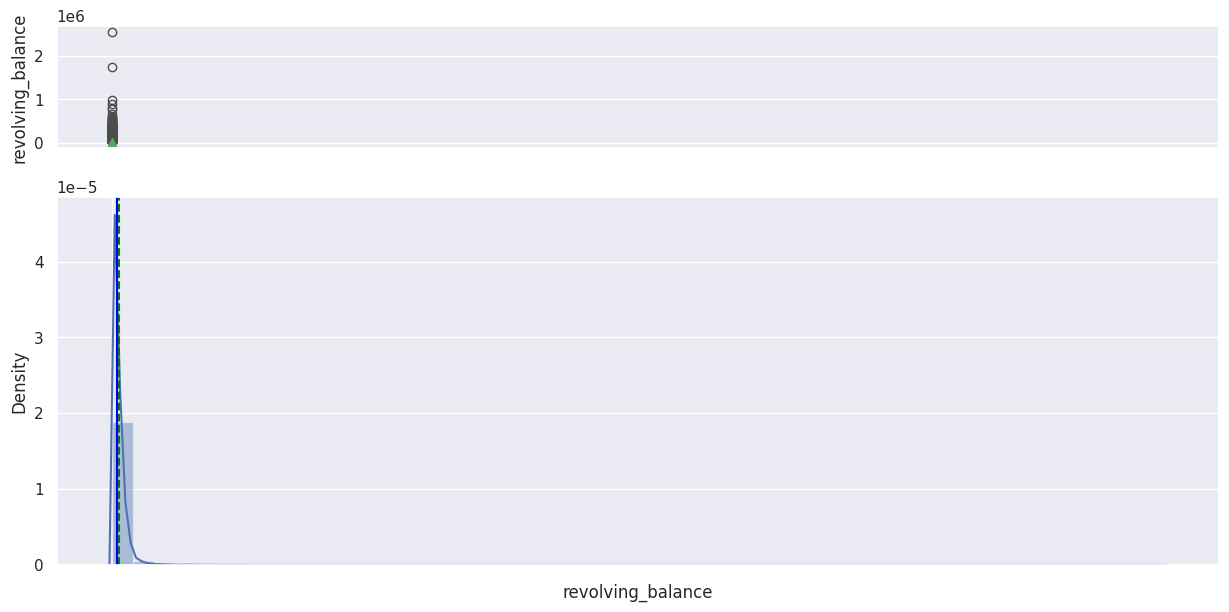

In [27]:
histogram_boxplot(df.revolving_balance)

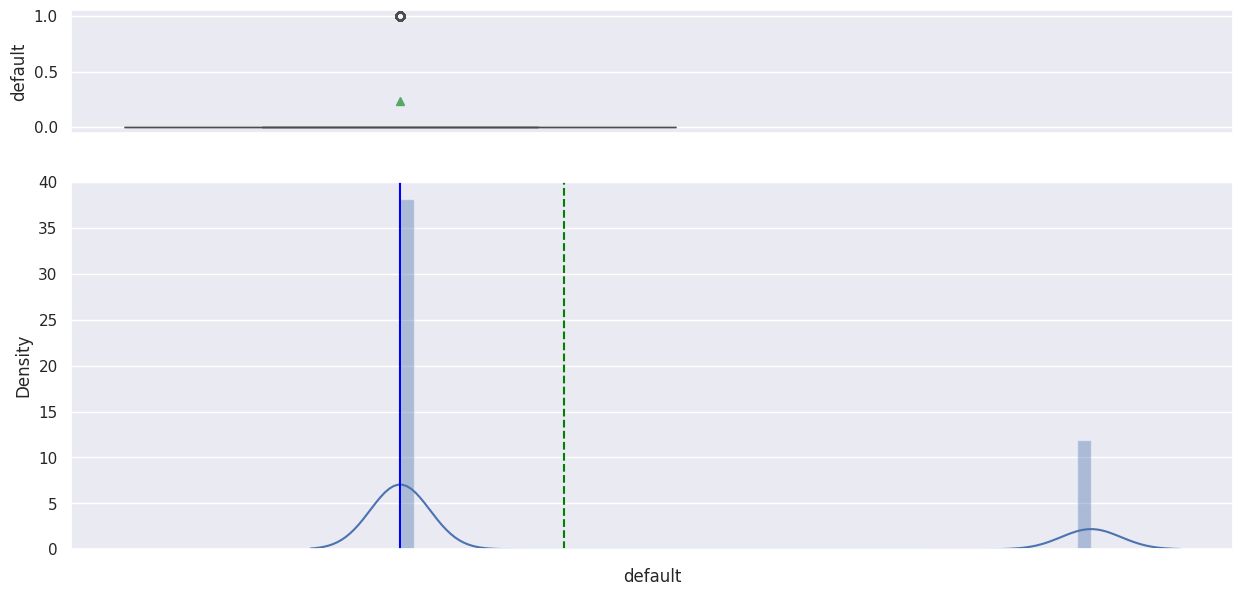

In [28]:
histogram_boxplot(df.default)

In [29]:
df.select_dtypes(include='float').columns

Index(['interest_rate', 'annual_income', 'debt_to_income', 'delinq_2yrs',
       'public_records', 'total_acc', 'interest_receive', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit'],
      dtype='object')

## interest_rate

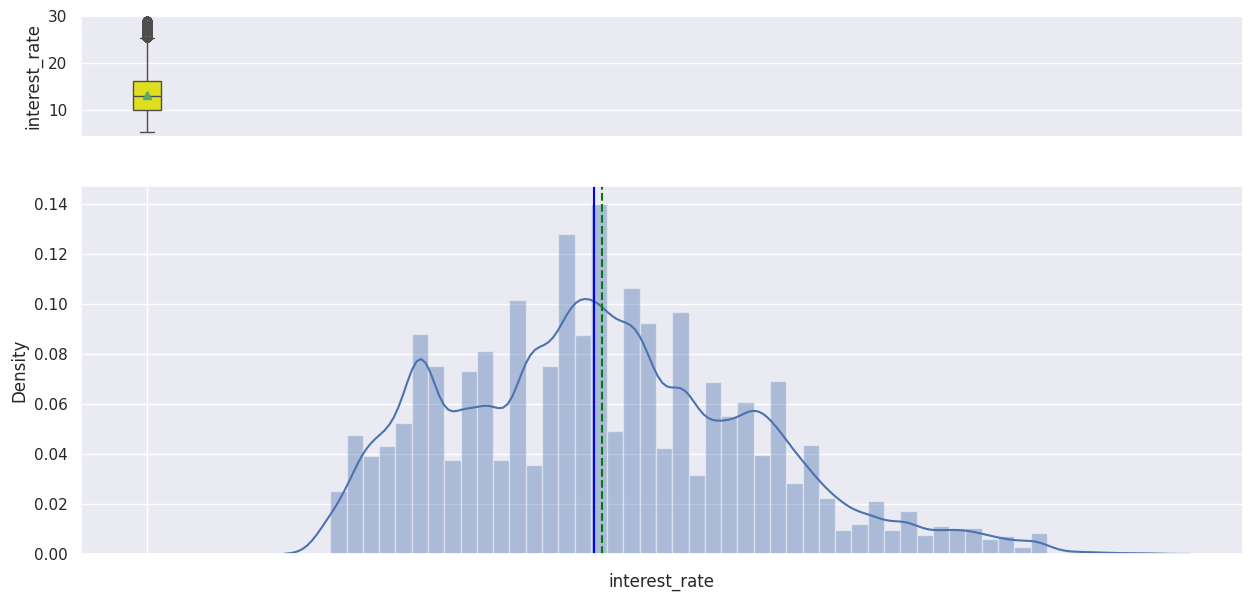

In [30]:
histogram_boxplot(df.interest_rate)

## annual_income

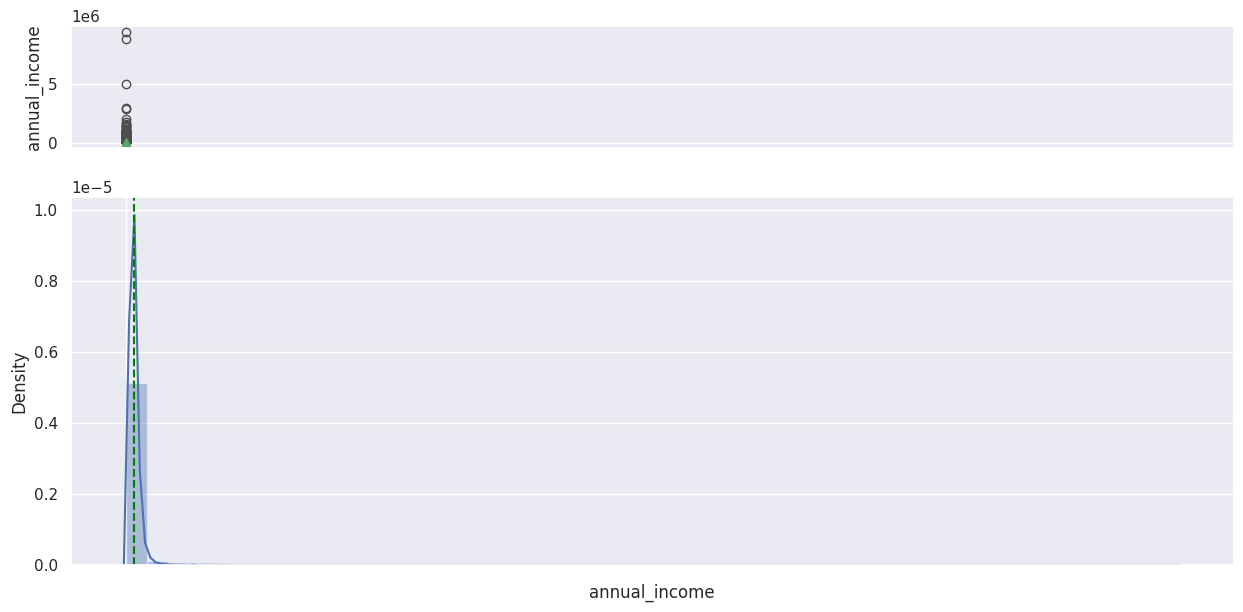

In [31]:
histogram_boxplot(df.annual_income)

## debt_to_income

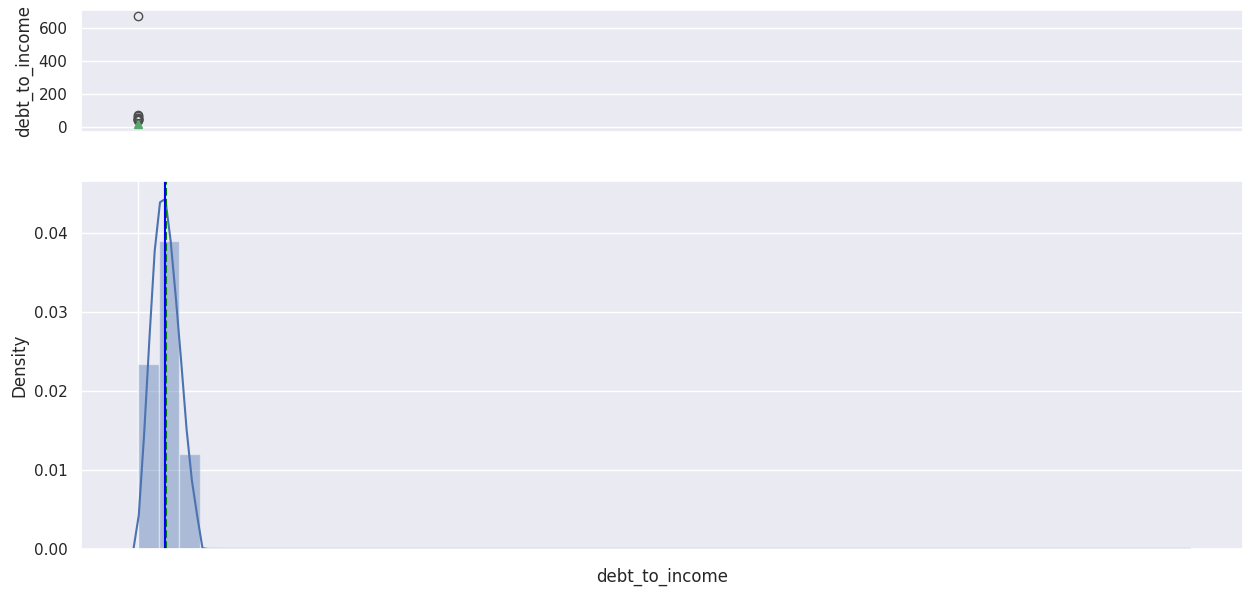

In [32]:
histogram_boxplot(df.debt_to_income)

## delinq_2yrs

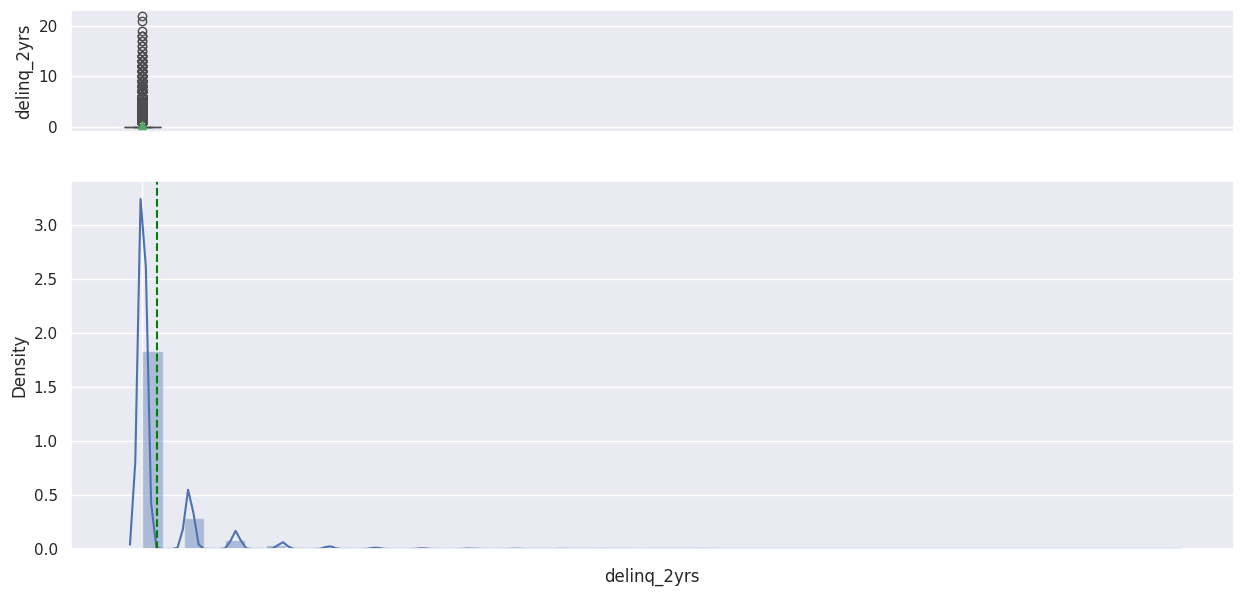

In [33]:
histogram_boxplot(df.delinq_2yrs)

## public_records

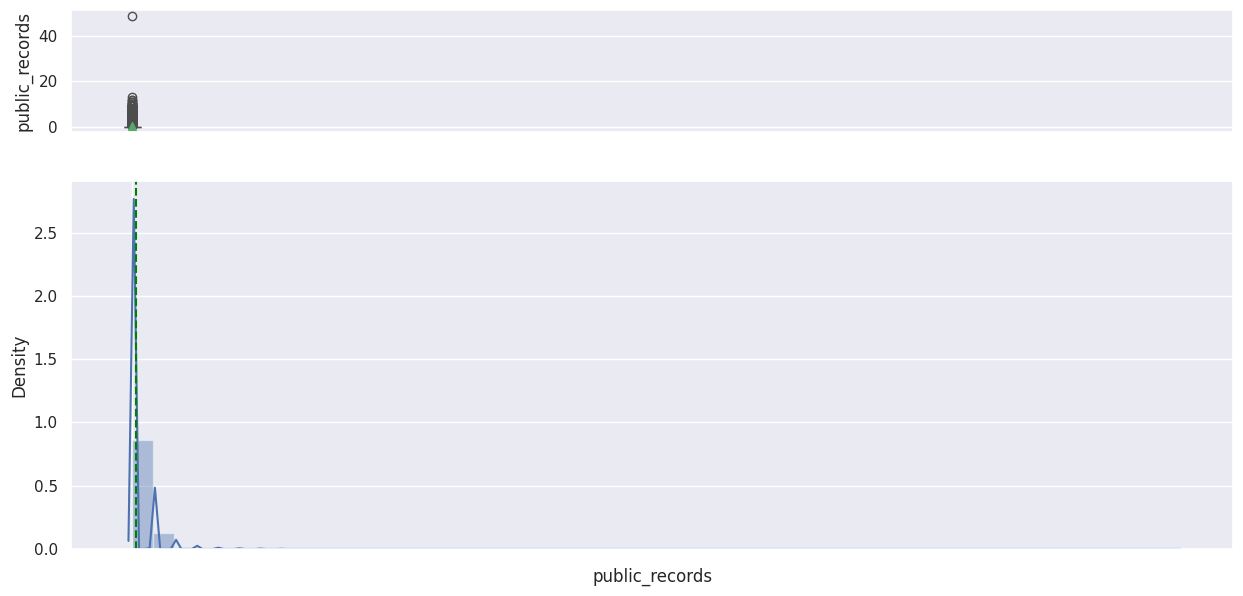

In [34]:
histogram_boxplot(df.public_records)

## total_acc

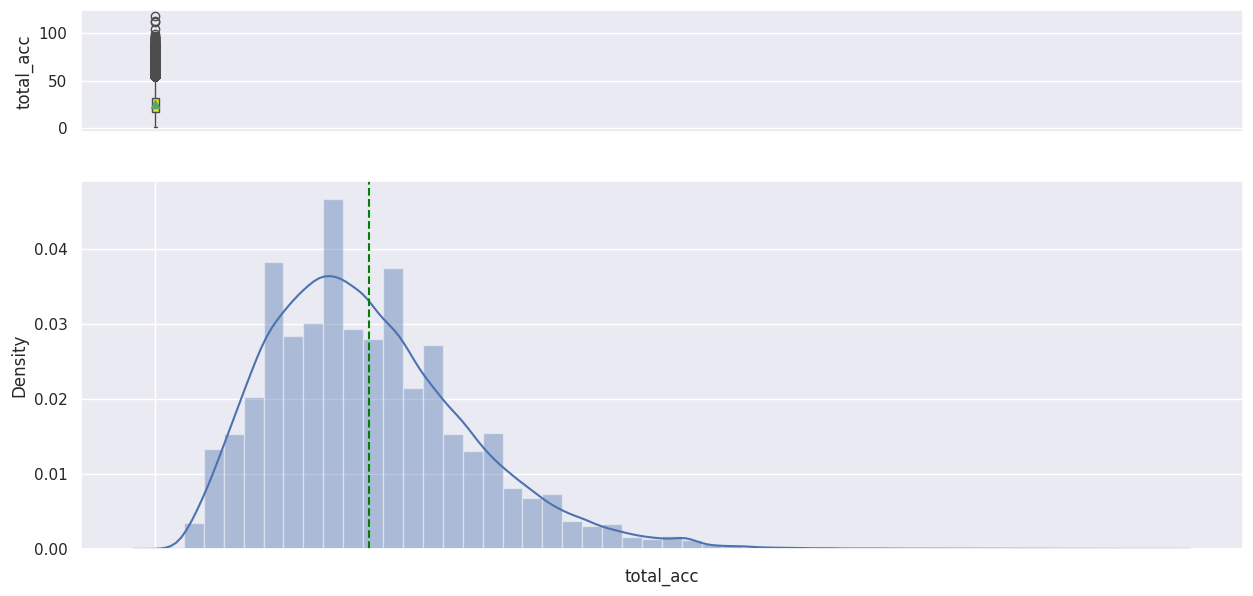

In [35]:
histogram_boxplot(df.total_acc)

## interest_receive

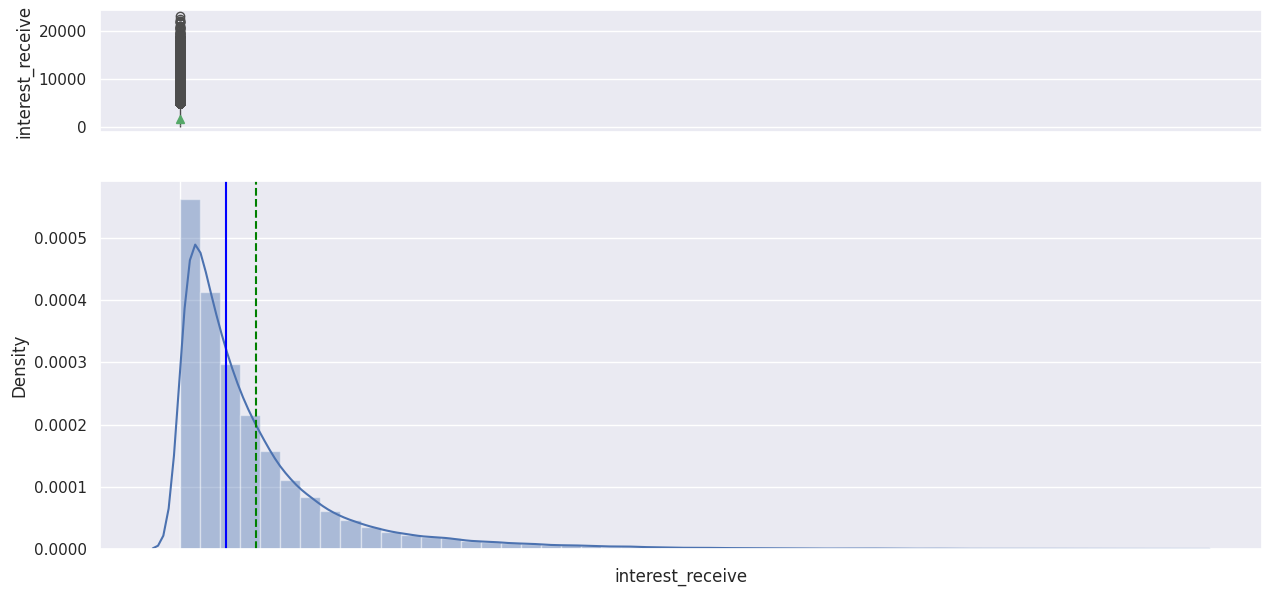

In [36]:
histogram_boxplot(df.interest_receive)

## last_week_pay

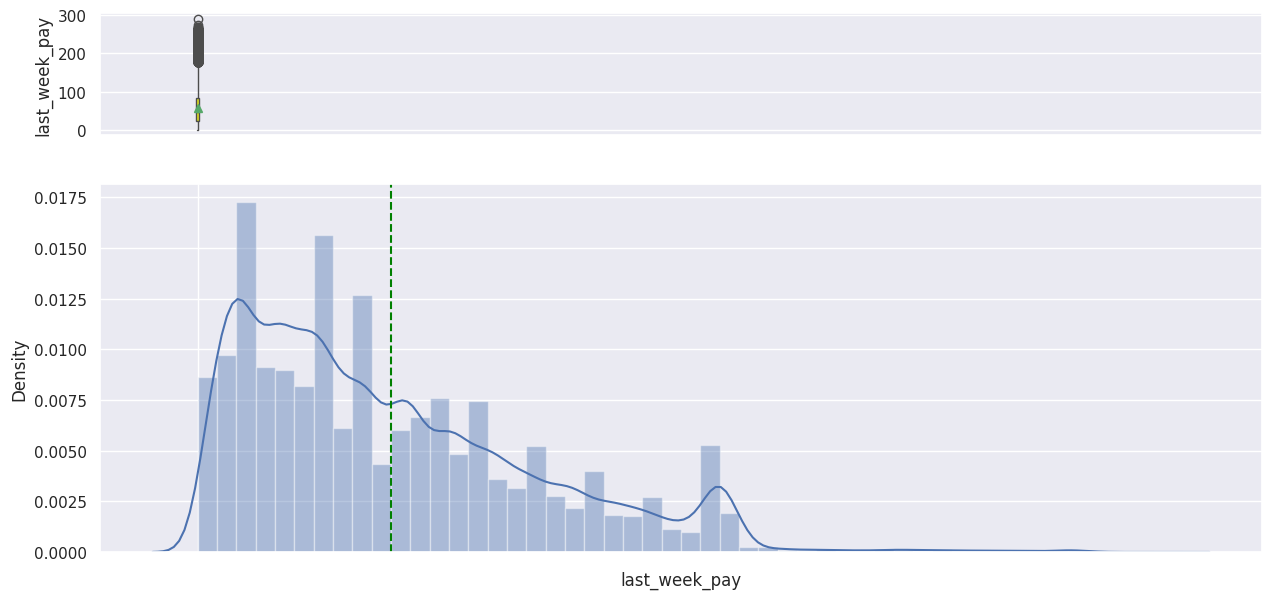

In [37]:
histogram_boxplot(df.last_week_pay)

## total_current_balance

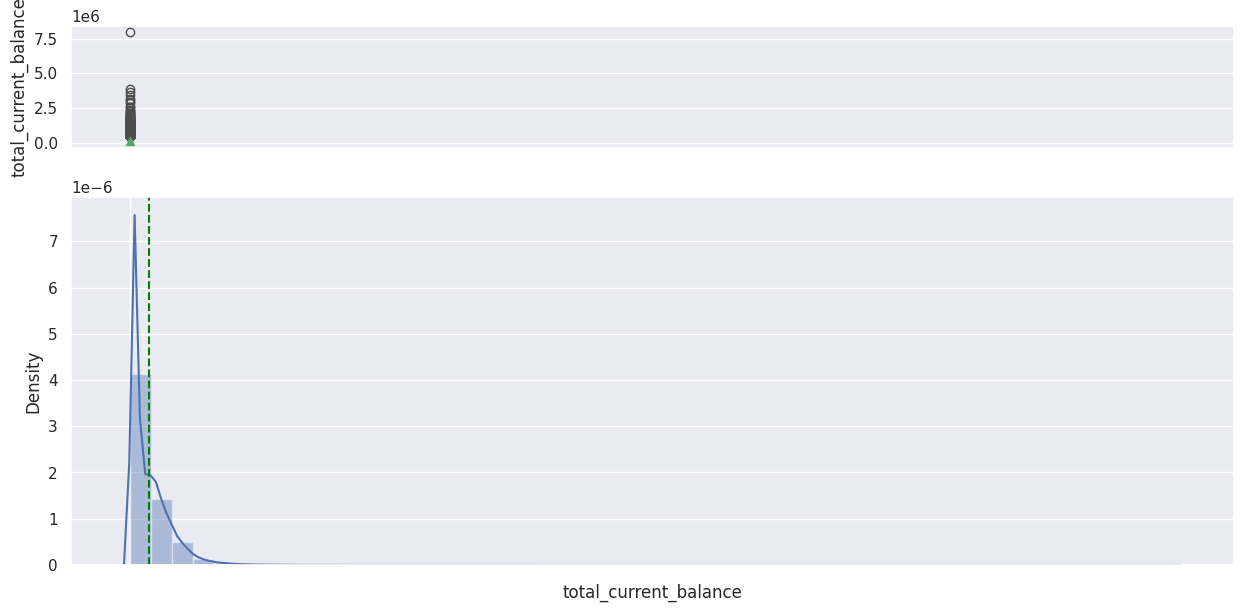

In [38]:
histogram_boxplot(df.total_current_balance)

## total_revolving_limit

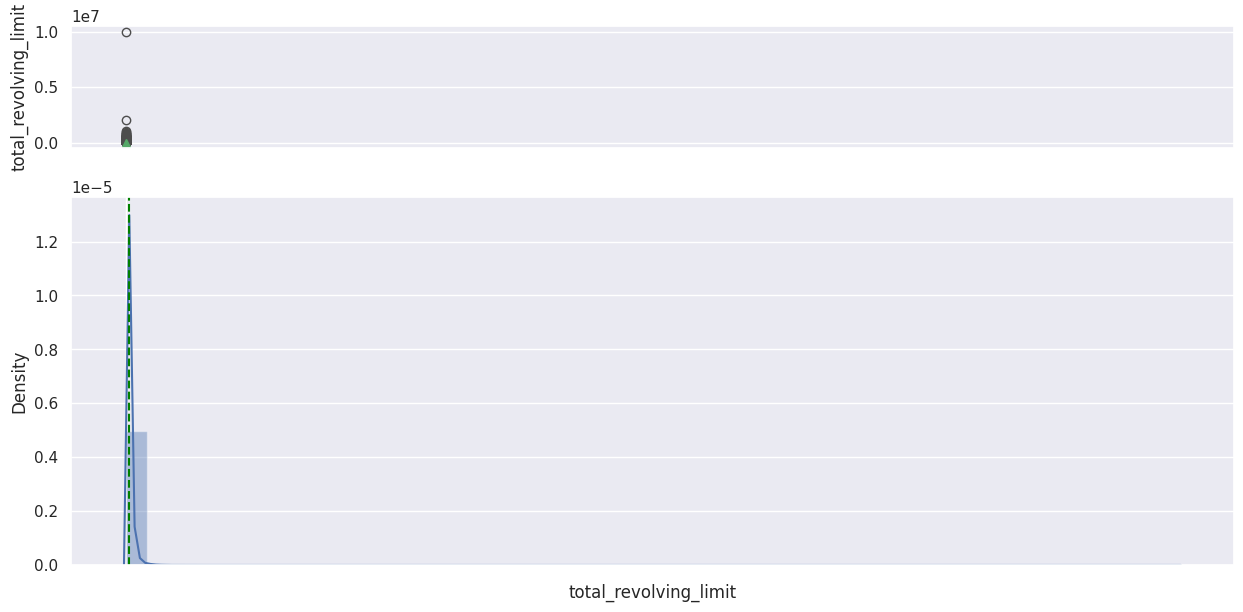

In [39]:
histogram_boxplot(df.total_revolving_limit)

## default

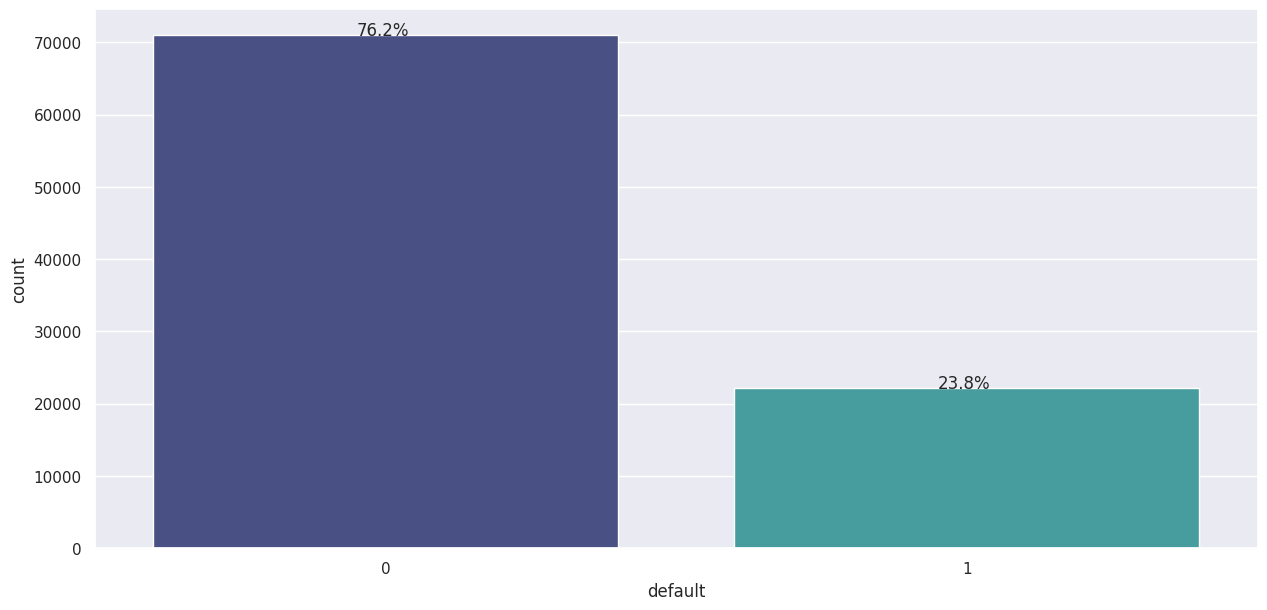

In [40]:
perc_on_bar(df.default)

## default

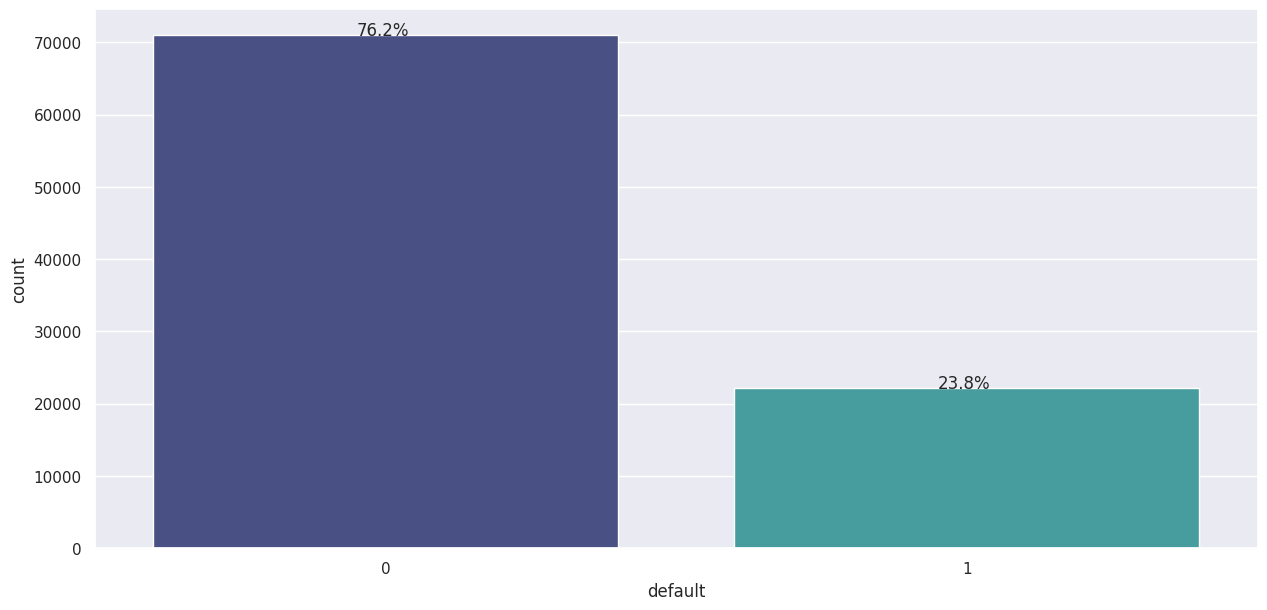

In [41]:
perc_on_bar(df.default)

## delinq_2yrs

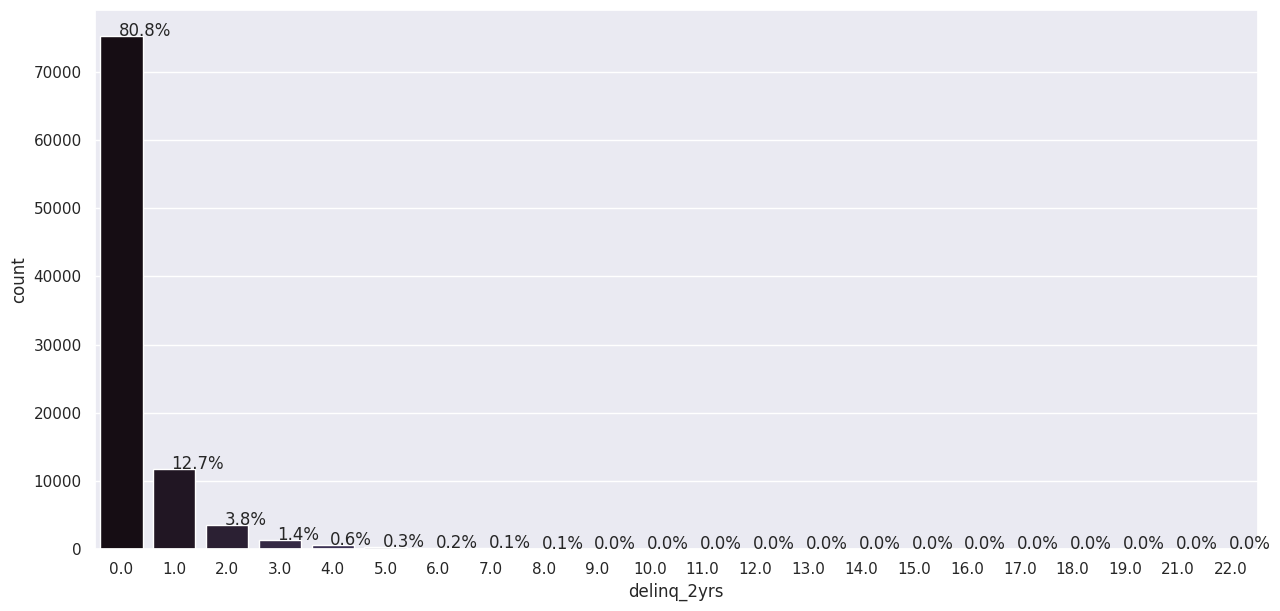

In [42]:
perc_on_bar(df.delinq_2yrs)

## public_records

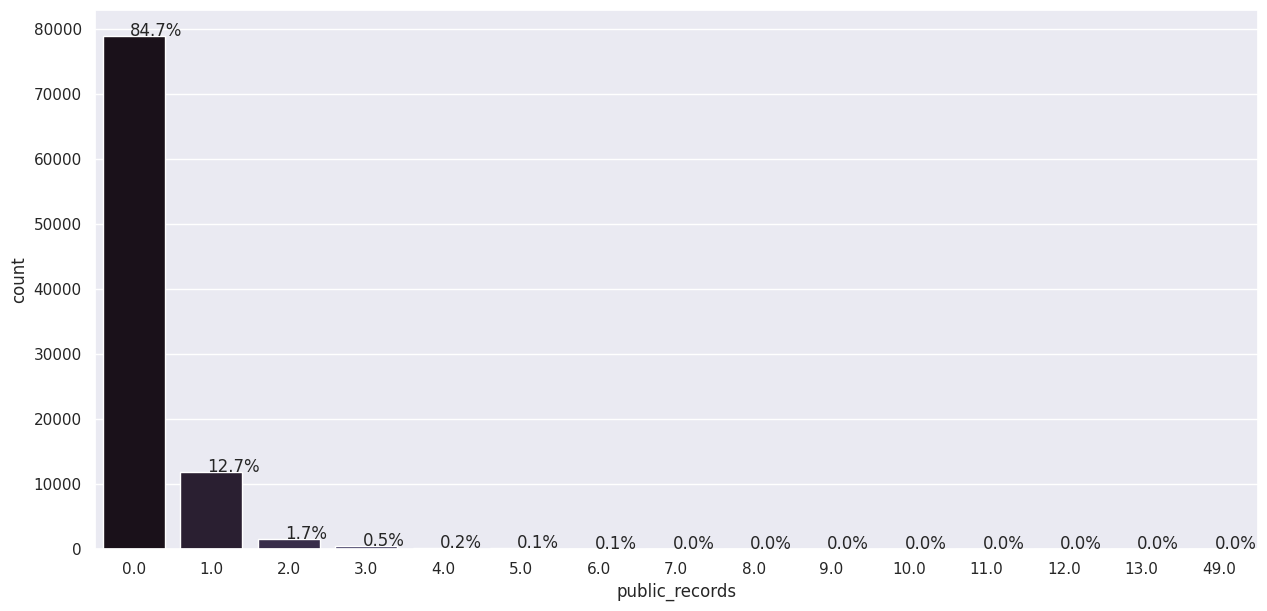

In [43]:
perc_on_bar(df.public_records)

## loan_term

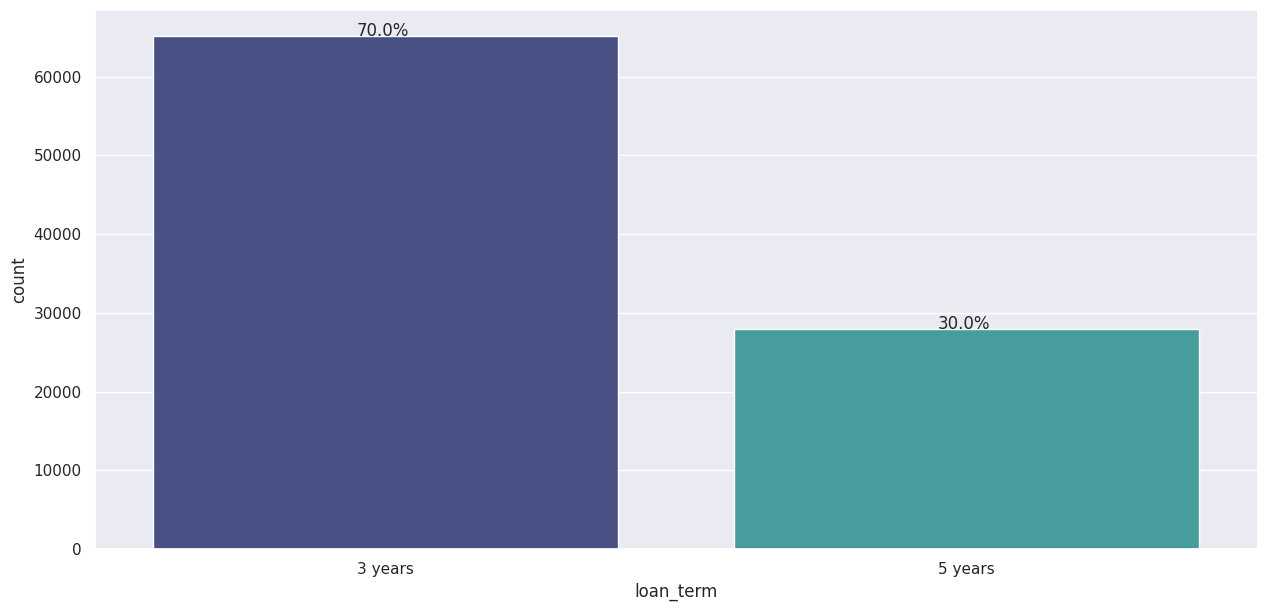

In [44]:
perc_on_bar(df.loan_term)

## loan_grade

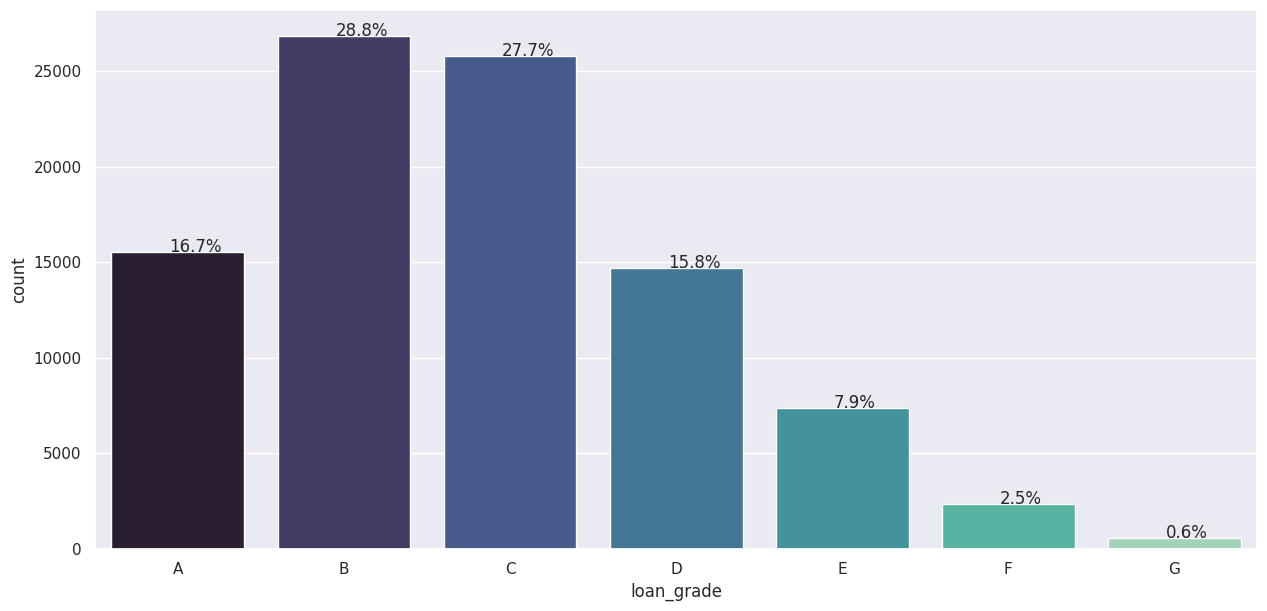

In [45]:
perc_on_bar(df.loan_grade)

## loan_subgrade

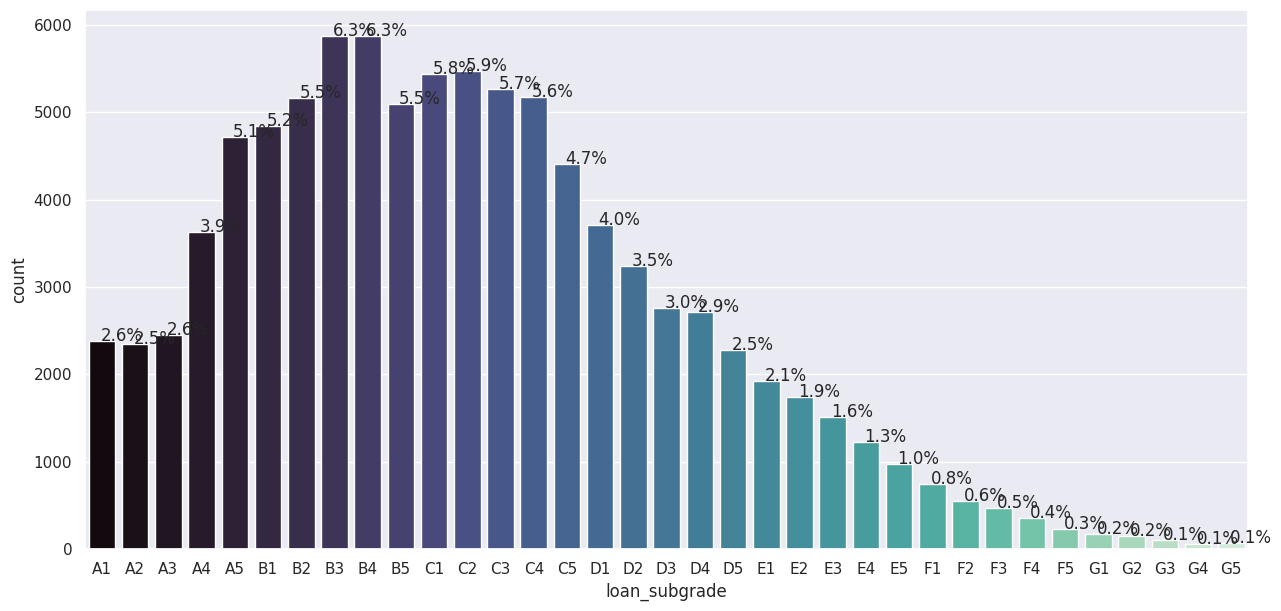

In [46]:
perc_on_bar(df.loan_subgrade)

## job_experience

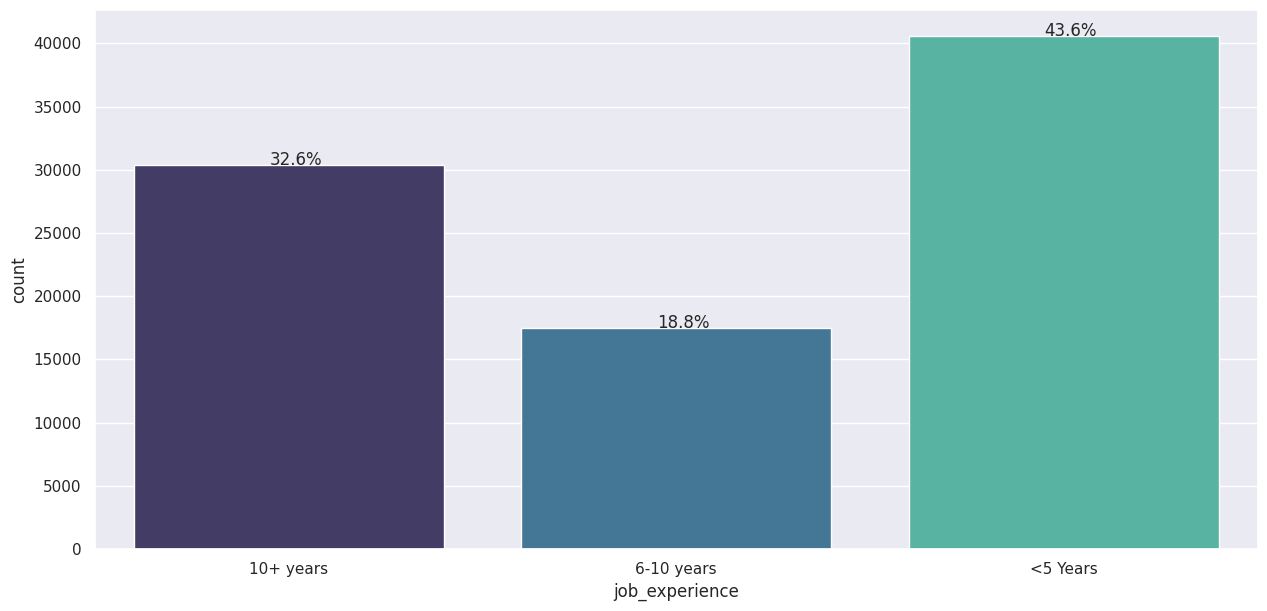

In [47]:
perc_on_bar(df.job_experience)

## home_ownership

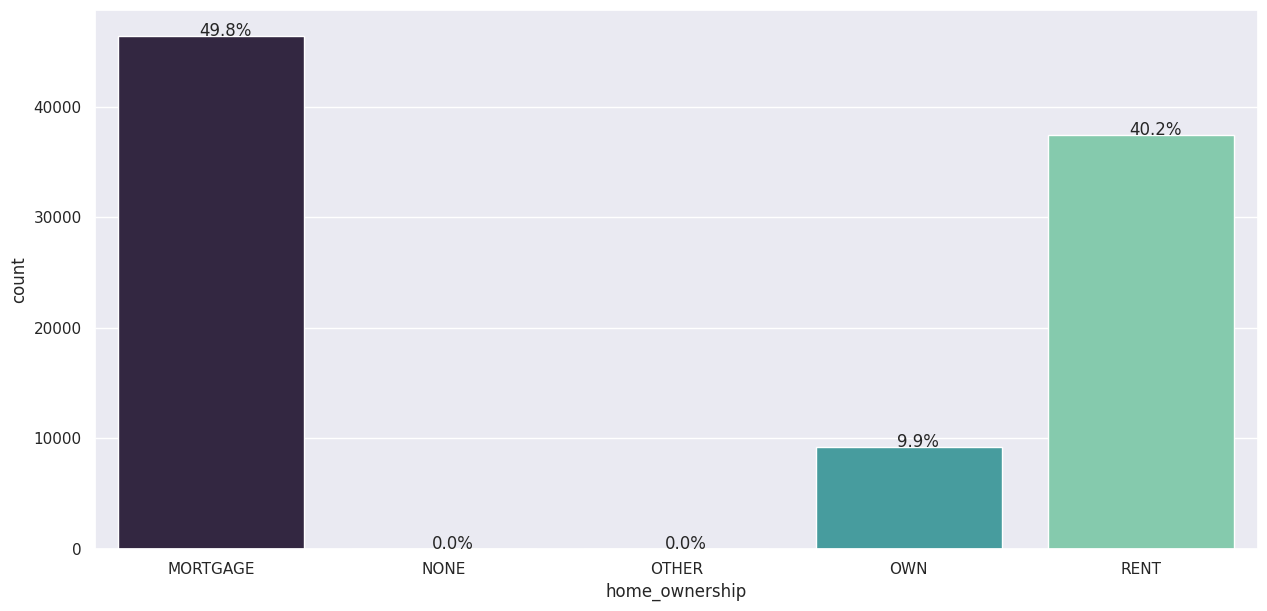

In [48]:
perc_on_bar(df.home_ownership)

## income_verification_status

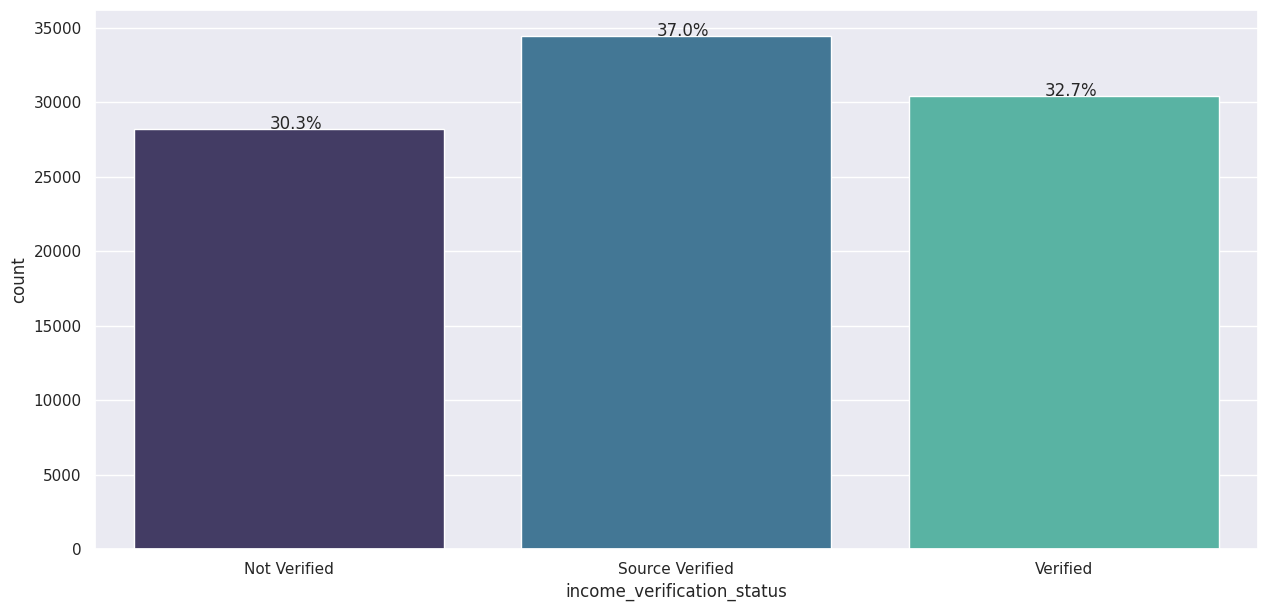

In [49]:
perc_on_bar(df.income_verification_status)

## loan_purpose

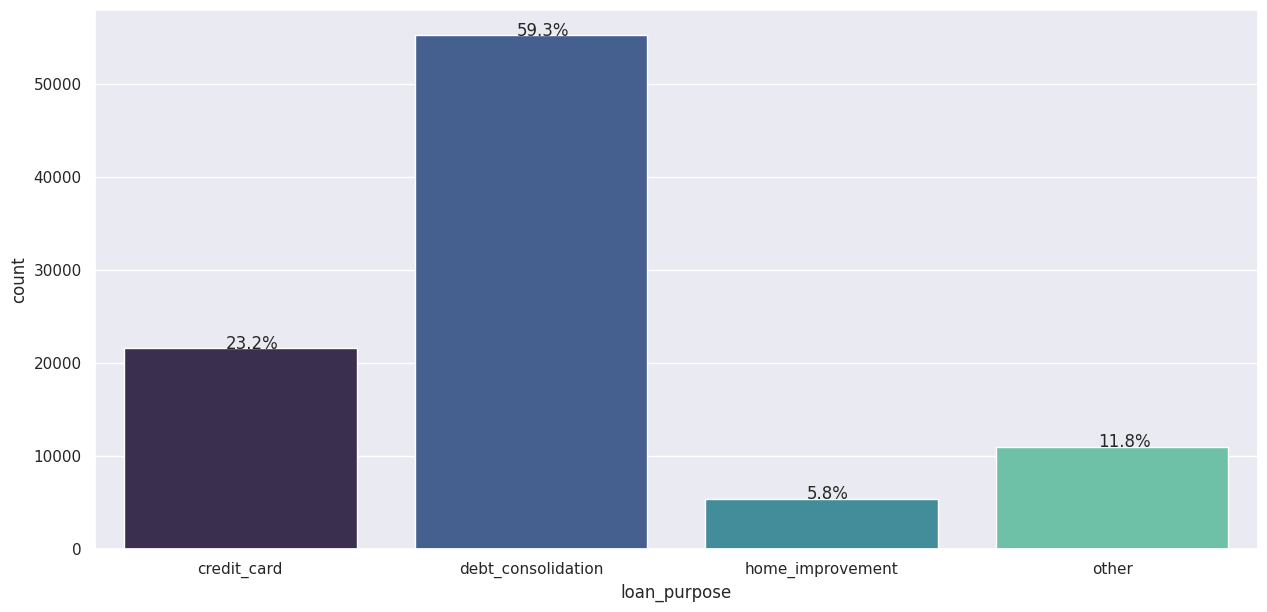

In [50]:
perc_on_bar(df.loan_purpose)

## state_code

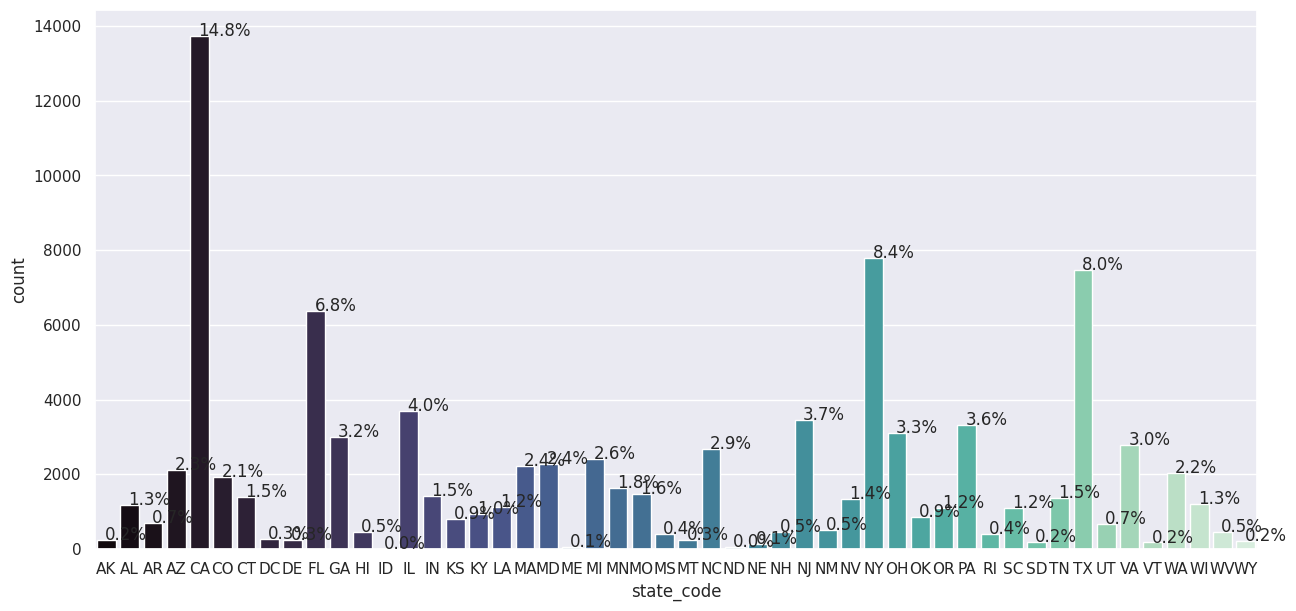

In [51]:
perc_on_bar(df.state_code)

## application_type

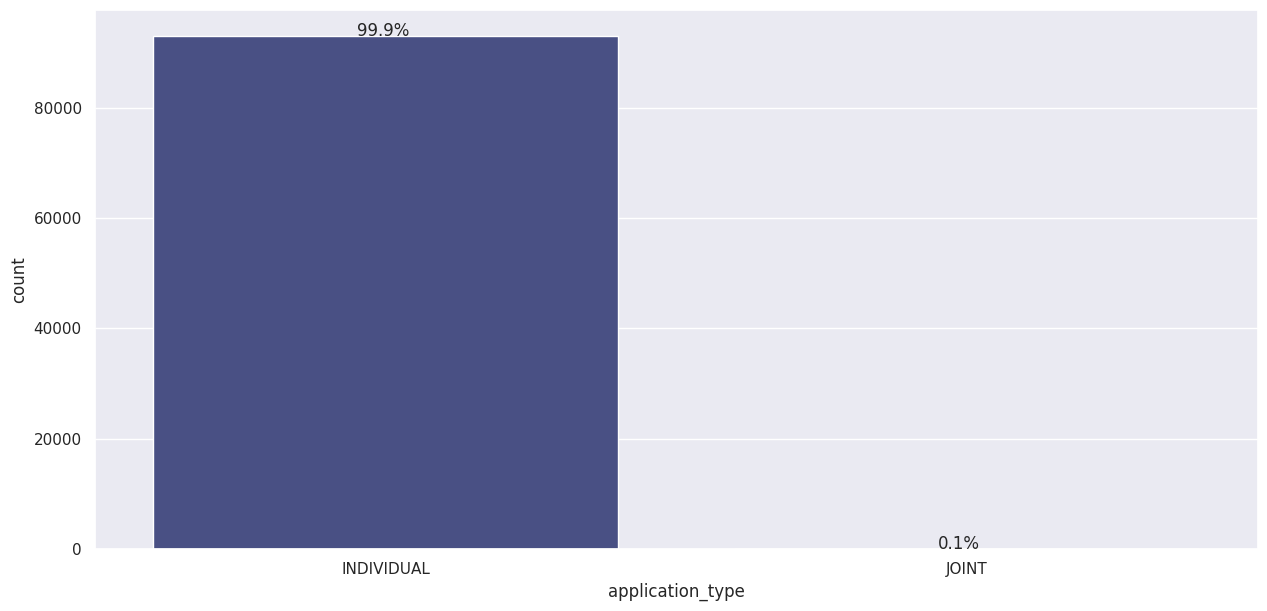

In [52]:
perc_on_bar(df.application_type)

## Bivariate Analysis

In [53]:
## Function to plot stacked bar chart
def stacked_plot(x, y, show_df=True):
    """
    Shows stacked plot from x and y pandas data series
    x: pandas data series
    y: pandas data series
    show_df: flag to show dataframe above plot (default=True)
    """
    if show_df == True:
        info = pd.crosstab(x, y, margins=True)
        info['% - 0'] = round(info[0]/info['All']*100, 2)
        info['% - 1'] = round(info[1]/info['All']*100, 2)
        display(info)

    pd.crosstab(x, y, normalize='index').plot(kind='bar', stacked=True, figsize=(10,5));

In [54]:
def show_boxplots(cols: list, feature: str, show_fliers=True, data=df): #method call to show bloxplots
    """
    Shows boxplots from pandas data series
    cols: list of column names
    feature: dataframe categorical feature
    """
    n_rows = math.ceil(len(cols)/3)
    plt.figure(figsize=(15, n_rows*5))
    for i, variable in enumerate(cols):
        plt.subplot(n_rows, 3, i+1)
        if show_fliers:
            sns.boxplot(data[feature], data[variable], palette="mako", showfliers=True)
        else:
            sns.boxplot(data[feature], data[variable], palette="mako", showfliers=False)
        plt.tight_layout()
        plt.title(variable, fontsize=12)
    plt.show()

In [55]:
### Function to plot distributions and Boxplots of customers
def plot_target(x, target='default'):
    fig,axs = plt.subplots(2,2,figsize=(12,10))
    axs[0, 0].set_title('Distribution of DEFAULT')
    sns.distplot(data[(data[target] == 1)][x], ax=axs[0,0], color='teal')
    axs[0, 1].set_title('Distribution of NON-DEFAULT')
    sns.distplot(data[(data[target] == 0)][x],ax=axs[0,1], color='orange')
    axs[1,0].set_title('Boxplot w.r.t default-flag')
    sns.boxplot(data[target],data[x],ax=axs[1,0], palette='mako')
    axs[1,1].set_title('Boxplot w.r.t default-flag - Without outliers')
    sns.boxplot(data[target],data[x], ax=axs[1,1], showfliers=False, palette='mako')
    plt.tight_layout()
    plt.show()

## Heat map

In [56]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(),annot=True,vmin=-1,vmax=1,fmt='.2f',cmap='coolwarm');

ValueError: could not convert string to float: 'INDIVIDUAL'

<Figure size 1500x700 with 0 Axes>

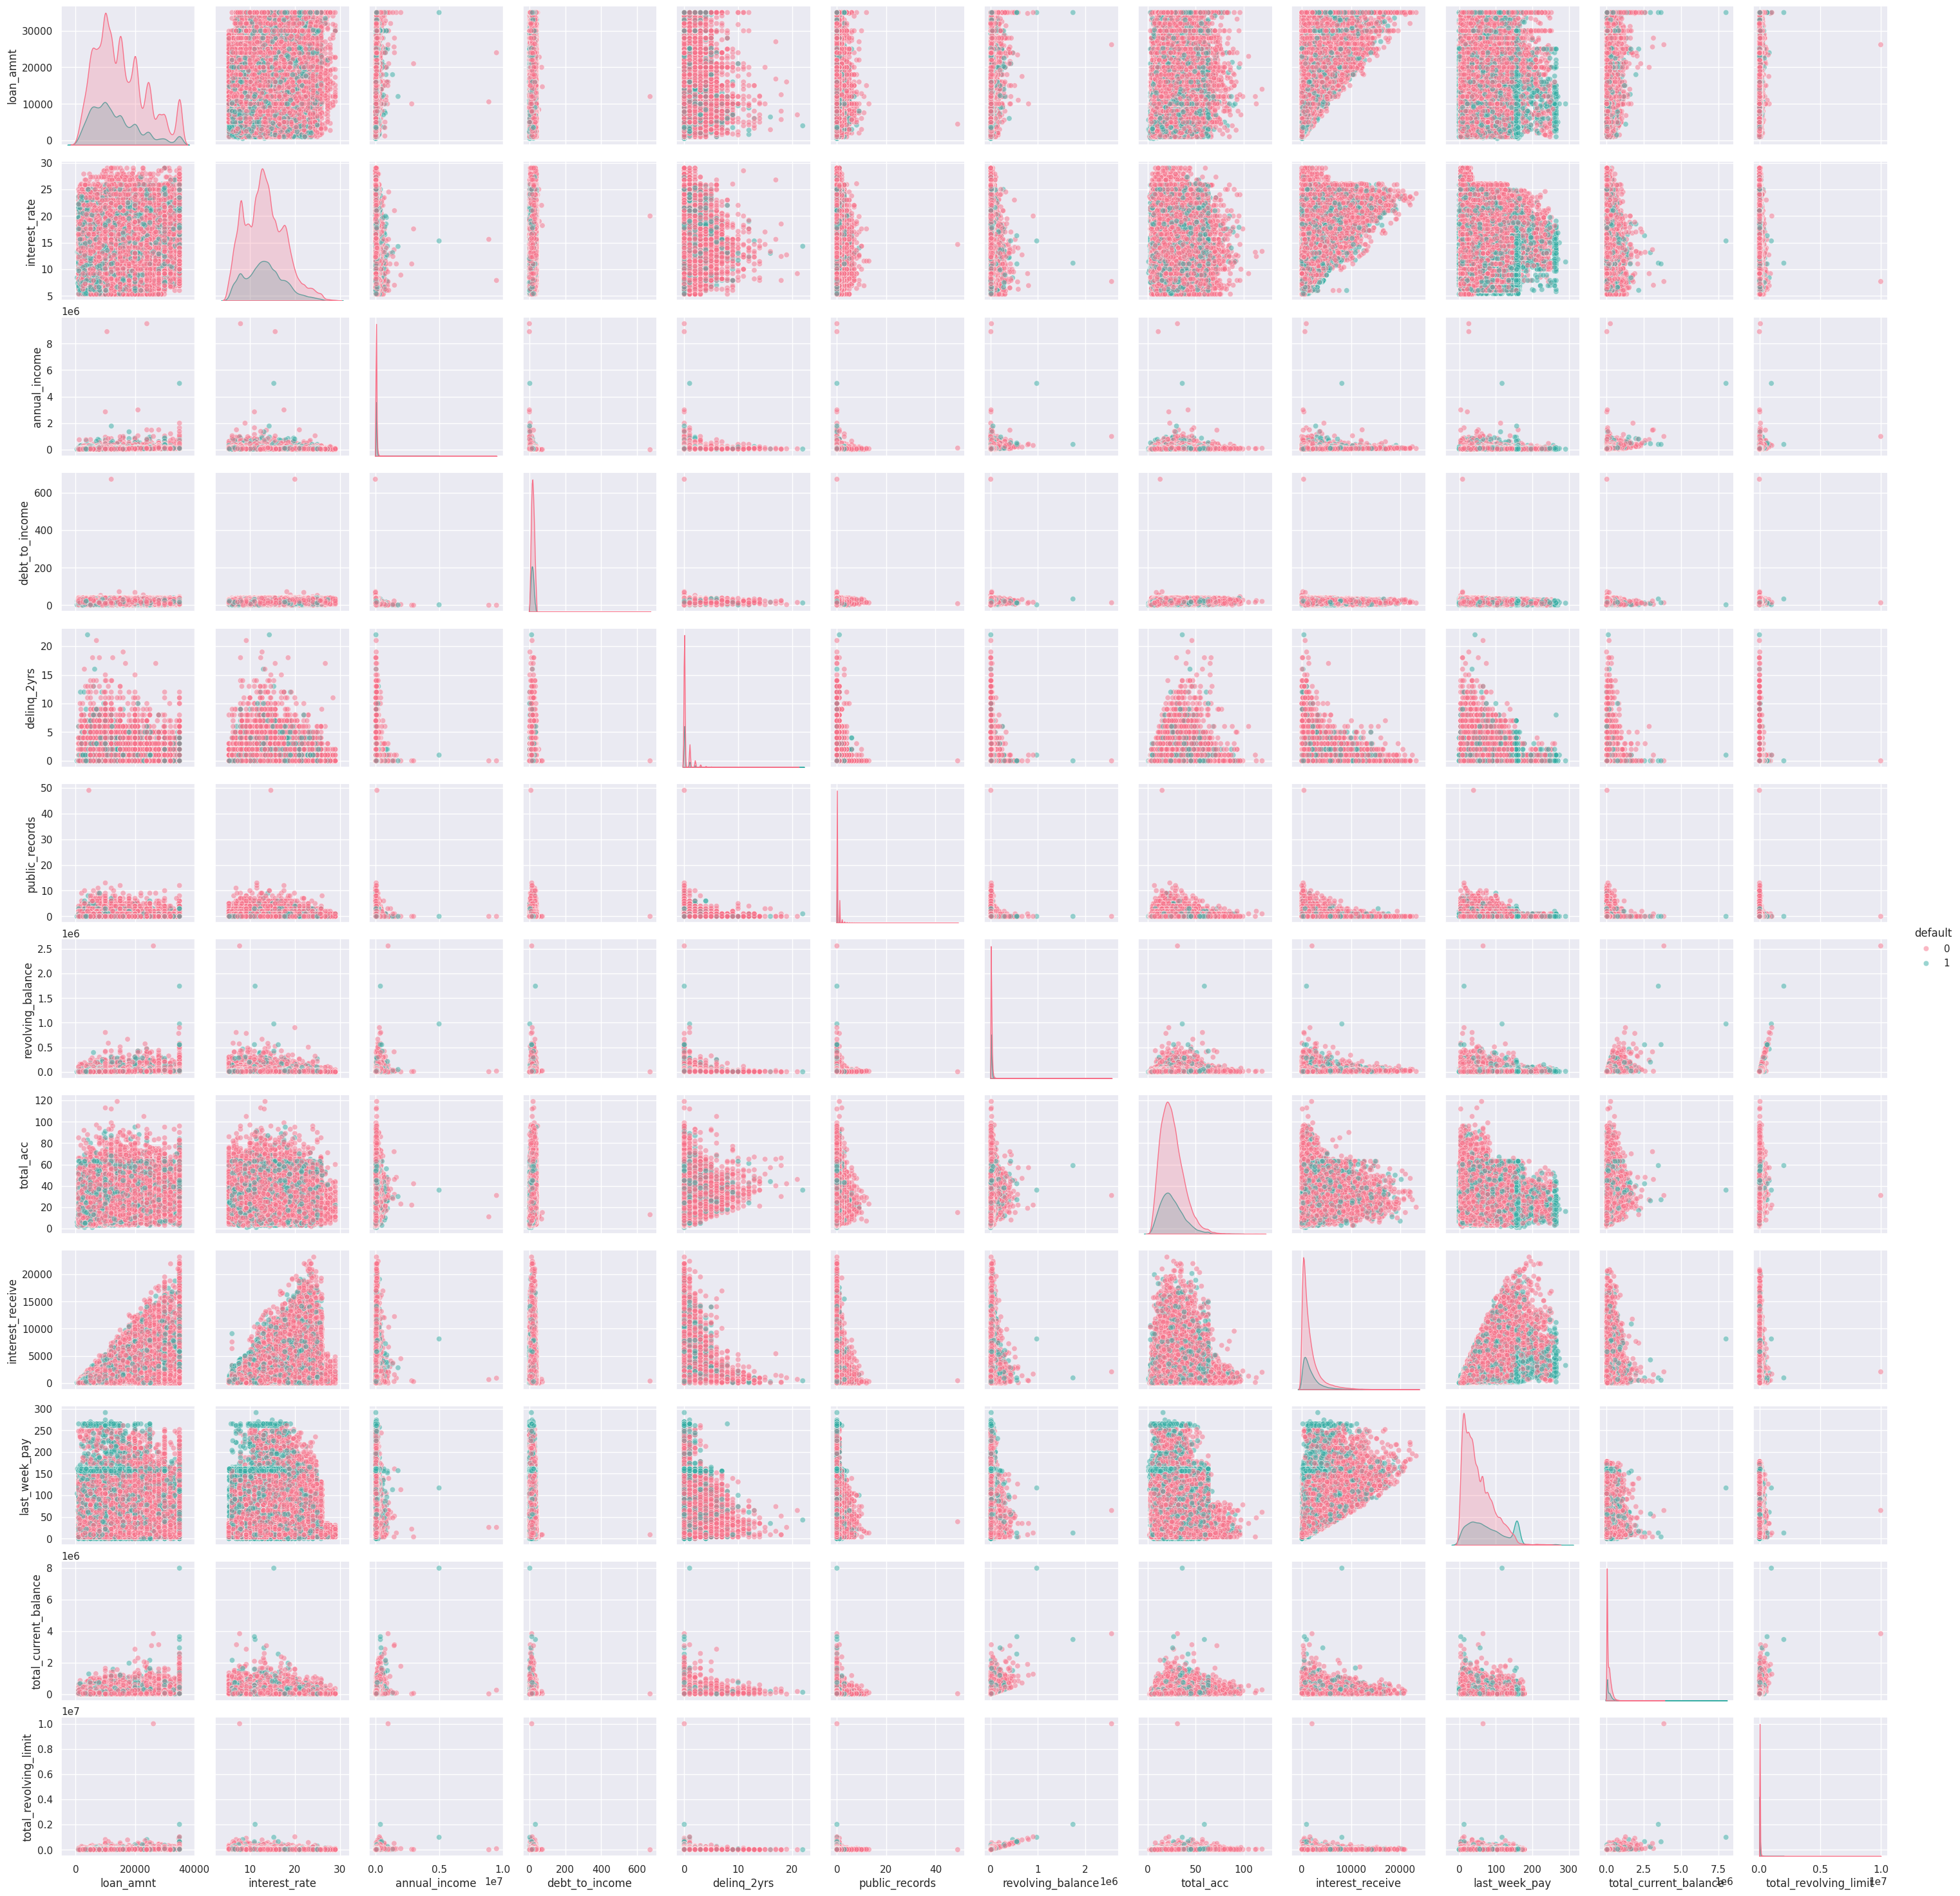

In [57]:
sns.pairplot(
    data=df,
    hue='default',
    palette='husl',
    plot_kws={'alpha': 0.5}
);

## default vs loan_term

default,0,1,All,% - 0,% - 1
loan_term,,,,,
3 years,47345,17866,65211,72.600,27.400
5 years,23700,4263,27963,84.750,15.250
All,71045,22129,93174,76.250,23.750


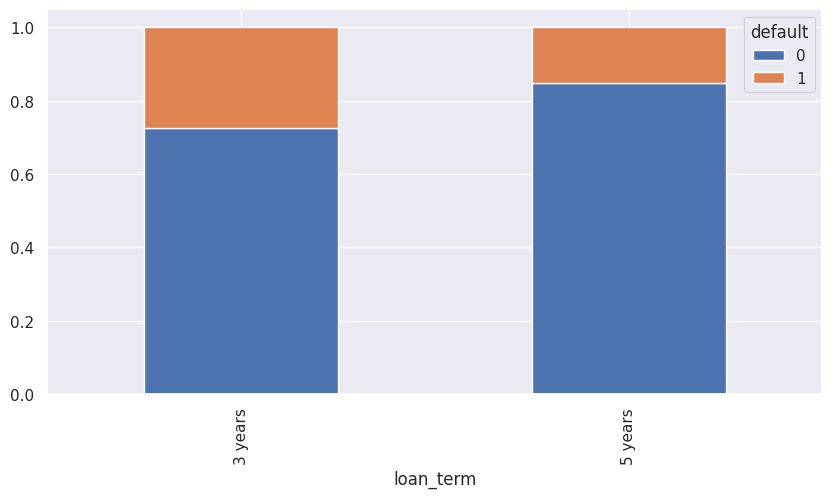

In [58]:
stacked_plot(df.loan_term, df.default)

## default vs loan_grade

default,0,1,All,% - 0,% - 1
loan_grade,,,,,
A,11281,4253,15534,72.620,27.380
B,19787,7078,26865,73.650,26.350
C,20203,5584,25787,78.350,21.650
D,11478,3237,14715,78.000,22.000
E,6003,1375,7378,81.360,18.640
F,1862,482,2344,79.440,20.560
G,431,120,551,78.220,21.780
All,71045,22129,93174,76.250,23.750


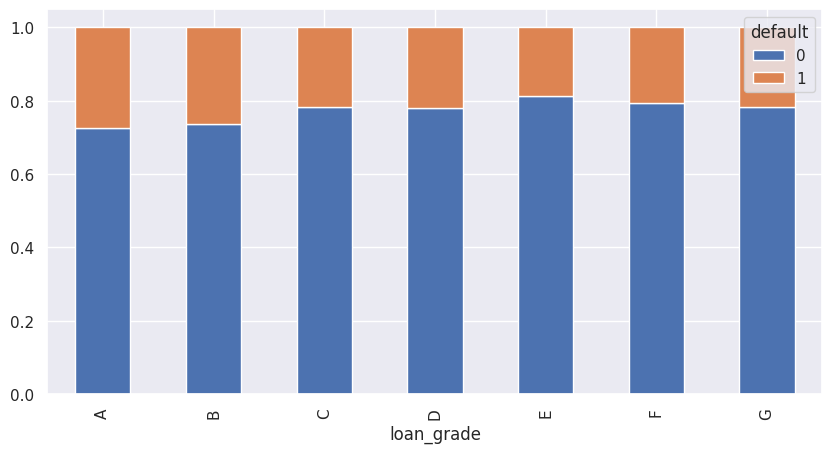

In [59]:
stacked_plot(df.loan_grade, df.default)

## default vs loan_subgrade

default,0,1,All,% - 0,% - 1
loan_subgrade,,,,,
A1,1780,597,2377,74.880,25.120
A2,1710,643,2353,72.670,27.330
A3,1731,719,2450,70.650,29.350
A4,2502,1129,3631,68.910,31.090
A5,3558,1165,4723,75.330,24.670
B1,3669,1174,4843,75.760,24.240
B2,3750,1419,5169,72.550,27.450
B3,4196,1683,5879,71.370,28.630
B4,4335,1544,5879,73.740,26.260


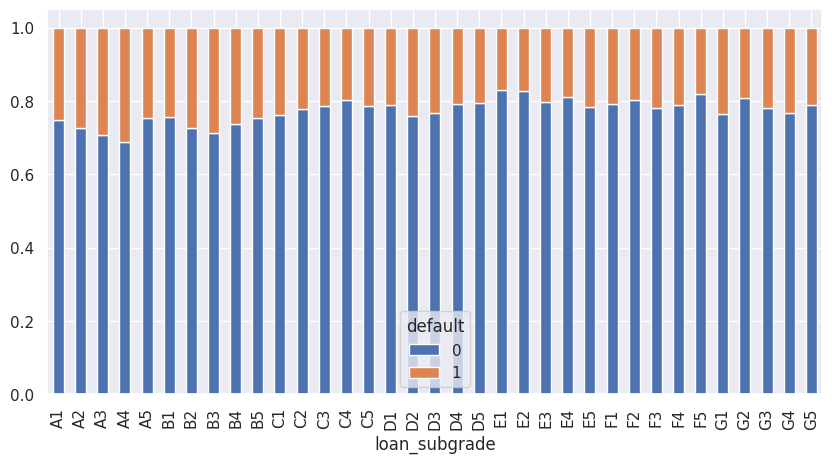

In [60]:
stacked_plot(df.loan_subgrade, df.default)

## default vs job_experience

default,0,1,All,% - 0,% - 1
job_experience,,,,,
10+ years,23656,6706,30362,77.910,22.090
6-10 years,13107,4393,17500,74.900,25.100
<5 Years,30377,10233,40610,74.800,25.200
All,67140,21332,88472,75.890,24.110


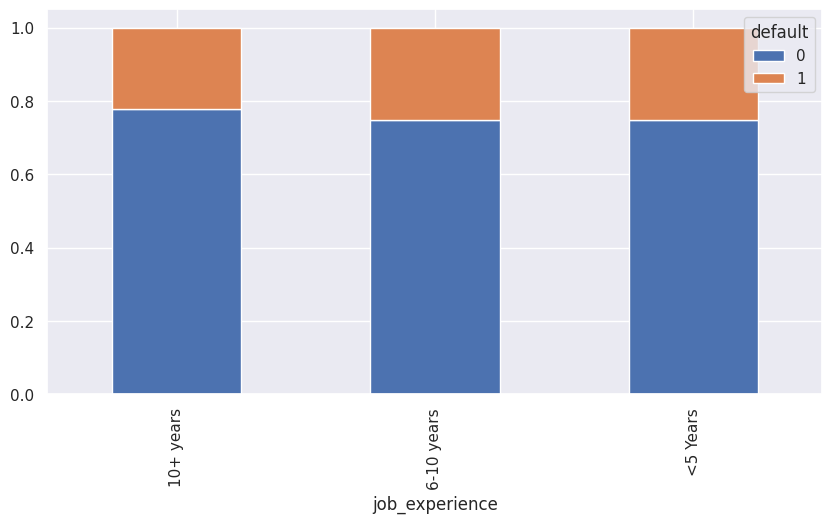

In [61]:
stacked_plot(df.job_experience, df.default)

## default vs home_ownership

default,0,1,All,% - 0,% - 1
home_ownership,,,,,
MORTGAGE,35316,11129,46445,76.040,23.960
NONE,2,6,8,25.000,75.000
OTHER,3,15,18,16.670,83.330
OWN,7323,1931,9254,79.130,20.870
RENT,28401,9048,37449,75.840,24.160
All,71045,22129,93174,76.250,23.750


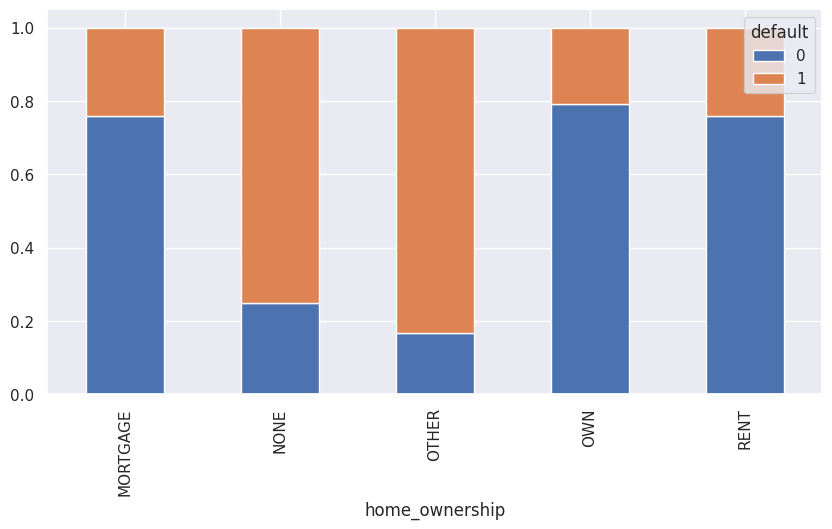

In [62]:
stacked_plot(df.home_ownership, df.default)

## default vs income_verification_status

default,0,1,All,% - 0,% - 1
income_verification_status,,,,,
Not Verified,20329,7908,28237,71.990,28.010
Source Verified,28062,6425,34487,81.370,18.630
Verified,22654,7796,30450,74.400,25.600
All,71045,22129,93174,76.250,23.750


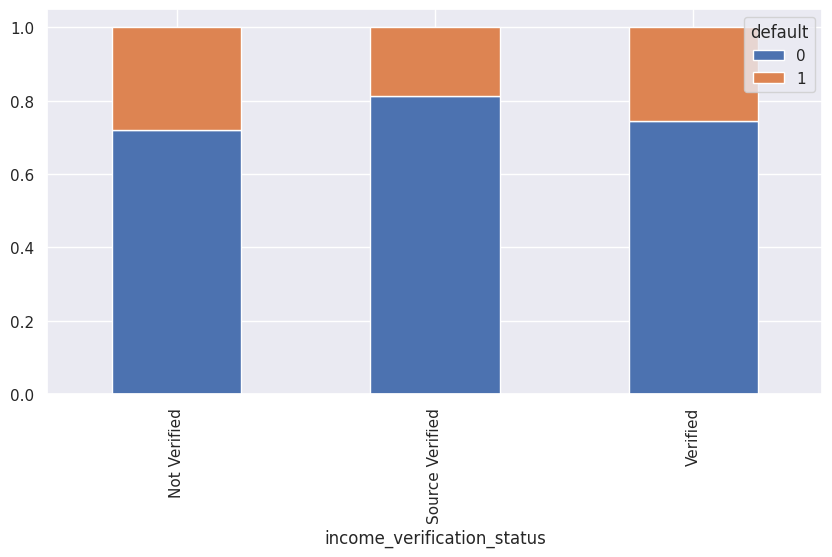

In [63]:
stacked_plot(df.income_verification_status, df.default)

## default vs loan_purpose

default,0,1,All,% - 0,% - 1
loan_purpose,,,,,
credit_card,17006,4565,21571,78.840,21.160
debt_consolidation,42408,12833,55241,76.770,23.230
home_improvement,4068,1323,5391,75.460,24.540
other,7563,3408,10971,68.940,31.060
All,71045,22129,93174,76.250,23.750


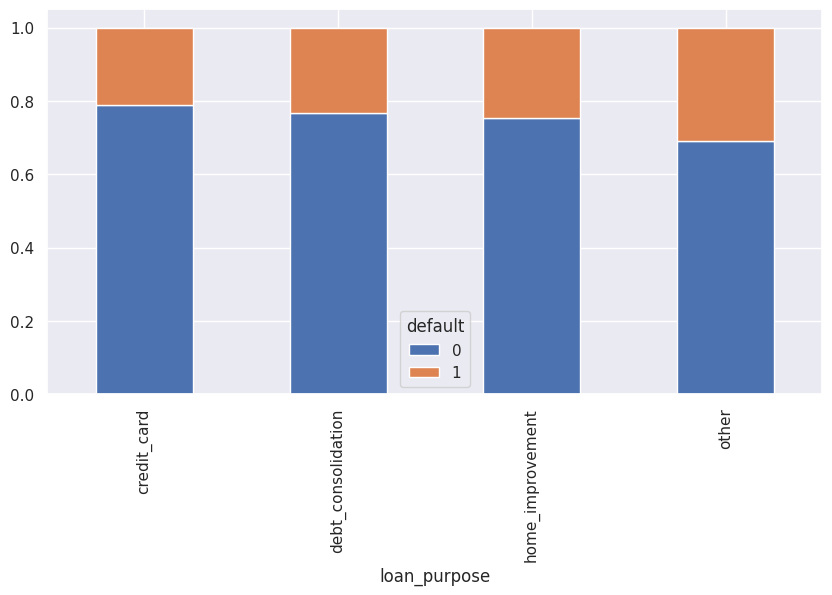

In [64]:
stacked_plot(df.loan_purpose, df.default)

## default vs state_code

default,0,1,All,% - 0,% - 1
state_code,,,,,
AK,170,61,231,73.590,26.410
AL,915,273,1188,77.020,22.980
AR,536,158,694,77.230,22.770
AZ,1583,532,2115,74.850,25.150
CA,9905,3839,13744,72.070,27.930
CO,1431,493,1924,74.380,25.620
CT,1083,319,1402,77.250,22.750
DC,183,88,271,67.530,32.470
DE,195,51,246,79.270,20.730


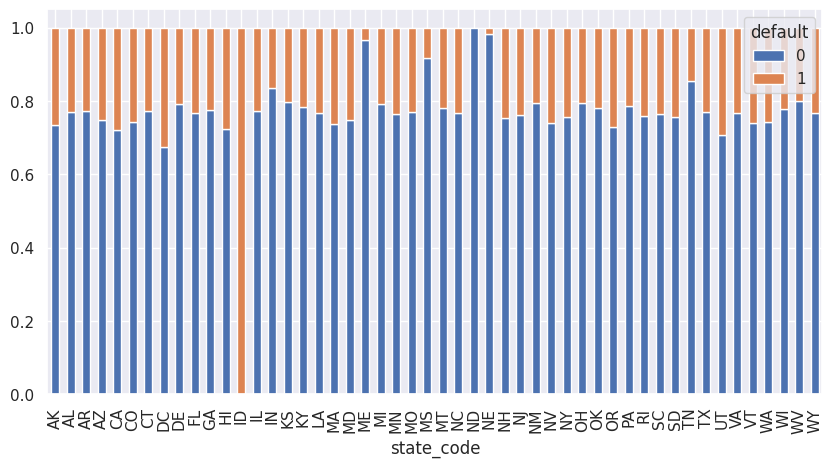

In [65]:
stacked_plot(df.state_code, df.default)

## default vs loan_term

default,0,1,All,% - 0,% - 1
loan_term,,,,,
3 years,47345,17866,65211,72.600,27.400
5 years,23700,4263,27963,84.750,15.250
All,71045,22129,93174,76.250,23.750


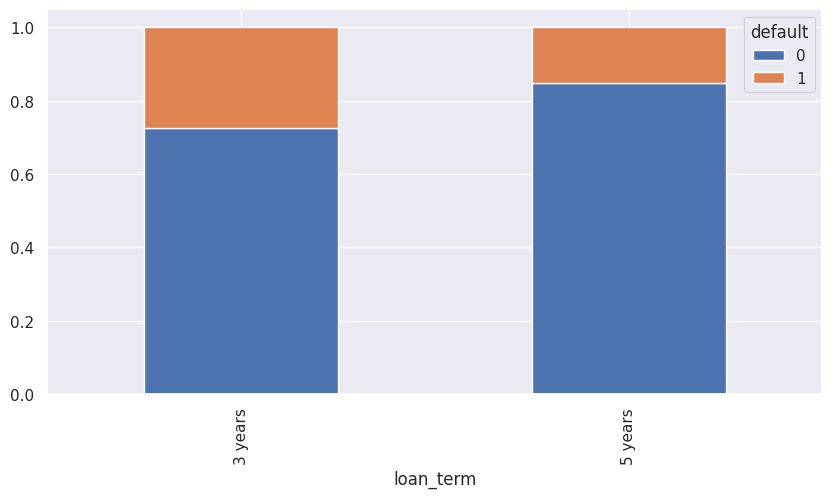

In [66]:
stacked_plot(df.loan_term, df.default)

## default vs loan_grade

default,0,1,All,% - 0,% - 1
loan_grade,,,,,
A,11281,4253,15534,72.620,27.380
B,19787,7078,26865,73.650,26.350
C,20203,5584,25787,78.350,21.650
D,11478,3237,14715,78.000,22.000
E,6003,1375,7378,81.360,18.640
F,1862,482,2344,79.440,20.560
G,431,120,551,78.220,21.780
All,71045,22129,93174,76.250,23.750


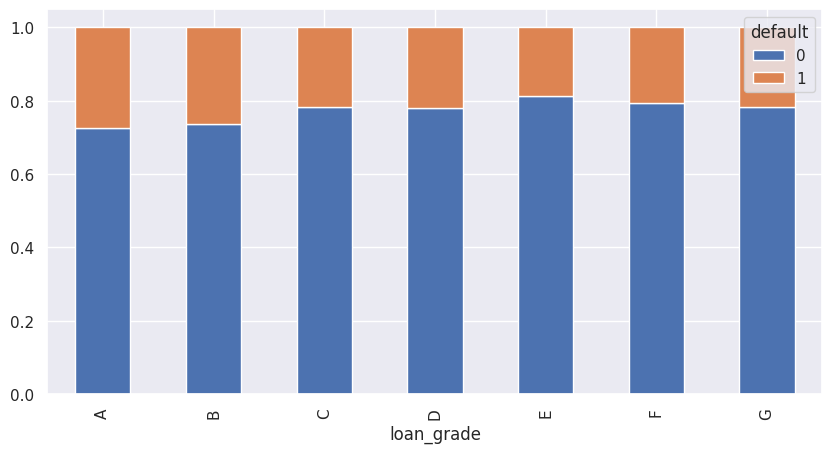

In [67]:
stacked_plot(df.loan_grade, df.default)

## default vs loan_subgrade

default,0,1,All,% - 0,% - 1
loan_subgrade,,,,,
A1,1780,597,2377,74.880,25.120
A2,1710,643,2353,72.670,27.330
A3,1731,719,2450,70.650,29.350
A4,2502,1129,3631,68.910,31.090
A5,3558,1165,4723,75.330,24.670
B1,3669,1174,4843,75.760,24.240
B2,3750,1419,5169,72.550,27.450
B3,4196,1683,5879,71.370,28.630
B4,4335,1544,5879,73.740,26.260


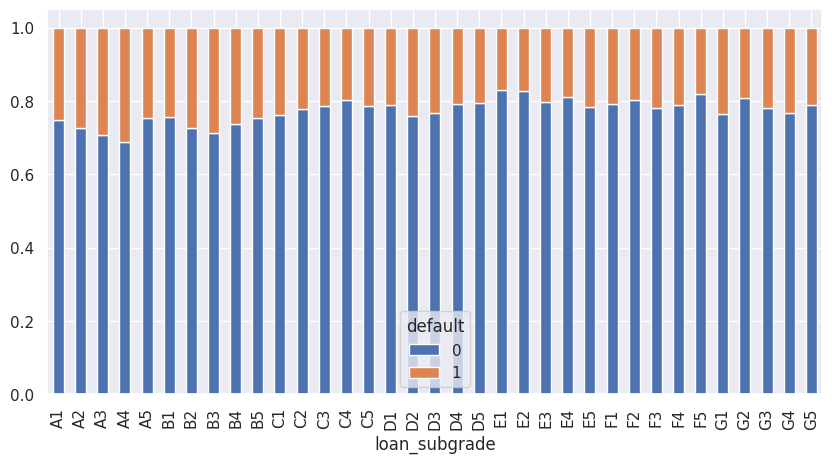

In [68]:
stacked_plot(df.loan_subgrade, df.default)

## default vs job_experience

In [ ]:
stacked_plot(df.job_experience, df.default)

## default vs home_ownership

default,0,1,All,% - 0,% - 1
home_ownership,,,,,
MORTGAGE,35316,11129,46445,76.040,23.960
NONE,2,6,8,25.000,75.000
OTHER,3,15,18,16.670,83.330
OWN,7323,1931,9254,79.130,20.870
RENT,28401,9048,37449,75.840,24.160
All,71045,22129,93174,76.250,23.750


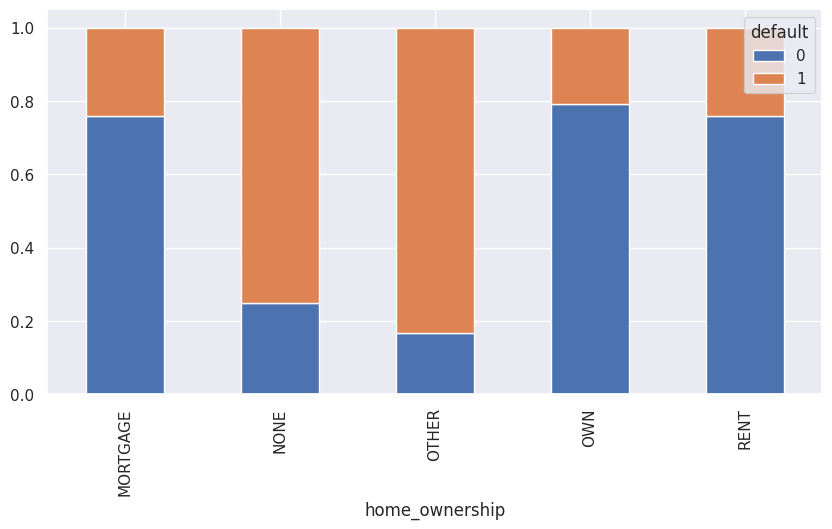

In [69]:
stacked_plot(df.home_ownership, df.default)

## default vs income_verification_status

default,0,1,All,% - 0,% - 1
income_verification_status,,,,,
Not Verified,20329,7908,28237,71.990,28.010
Source Verified,28062,6425,34487,81.370,18.630
Verified,22654,7796,30450,74.400,25.600
All,71045,22129,93174,76.250,23.750


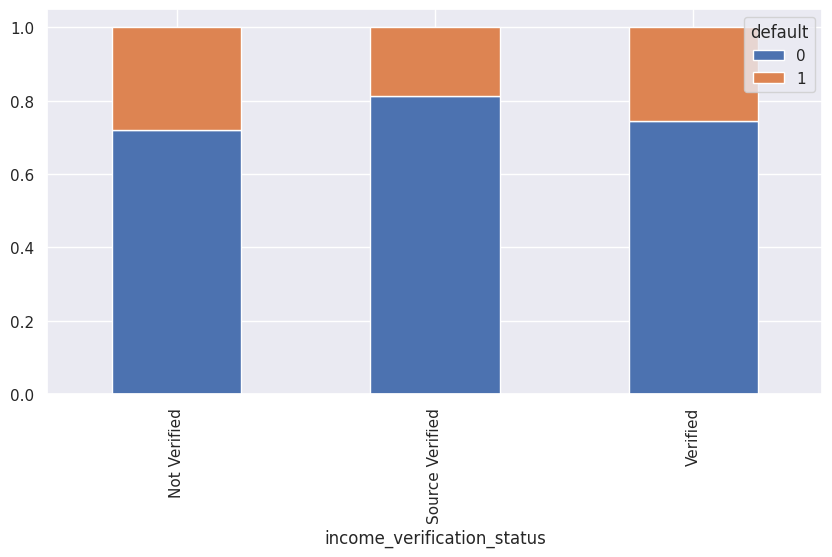

In [70]:
stacked_plot(df.income_verification_status, df.default)

## default vs loan_purpose

default,0,1,All,% - 0,% - 1
loan_purpose,,,,,
credit_card,17006,4565,21571,78.840,21.160
debt_consolidation,42408,12833,55241,76.770,23.230
home_improvement,4068,1323,5391,75.460,24.540
other,7563,3408,10971,68.940,31.060
All,71045,22129,93174,76.250,23.750


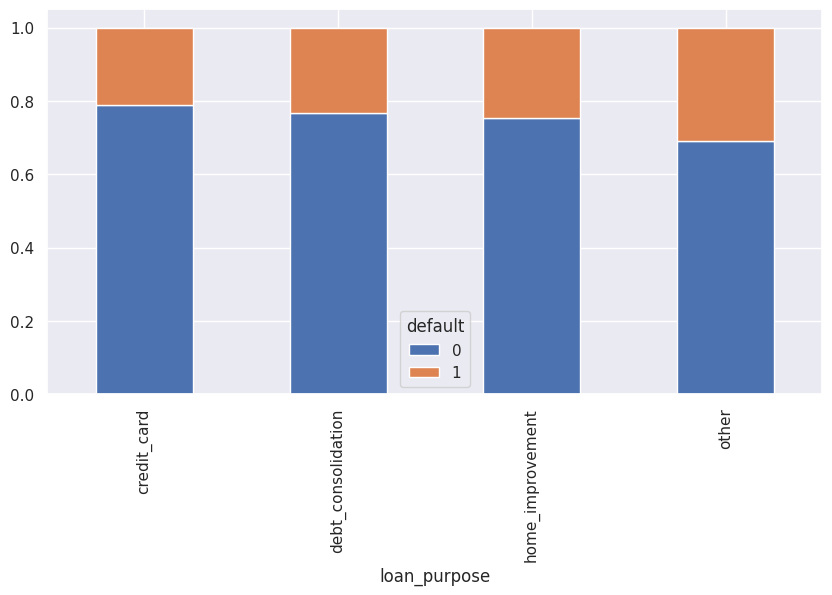

In [72]:
stacked_plot(df.loan_purpose, df.default)

## default vs state_code

default,0,1,All,% - 0,% - 1
state_code,,,,,
AK,170,61,231,73.590,26.410
AL,915,273,1188,77.020,22.980
AR,536,158,694,77.230,22.770
AZ,1583,532,2115,74.850,25.150
CA,9905,3839,13744,72.070,27.930
CO,1431,493,1924,74.380,25.620
CT,1083,319,1402,77.250,22.750
DC,183,88,271,67.530,32.470
DE,195,51,246,79.270,20.730


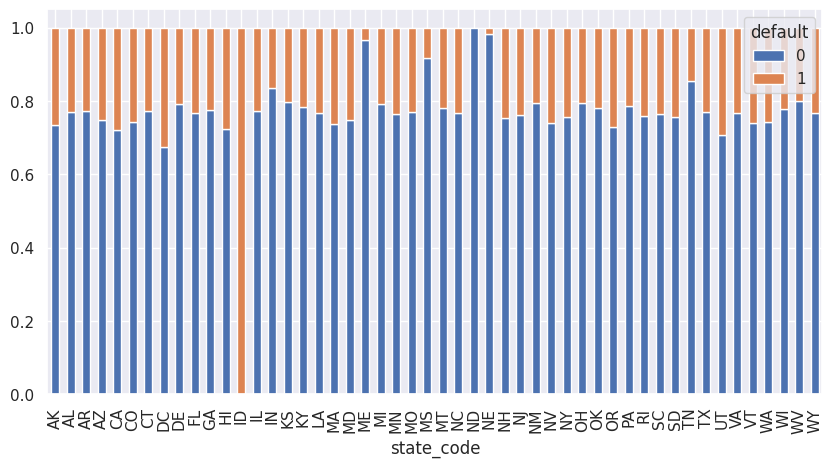

In [71]:
stacked_plot(df.state_code, df.default)

 With outliers 
 **************************************************


TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

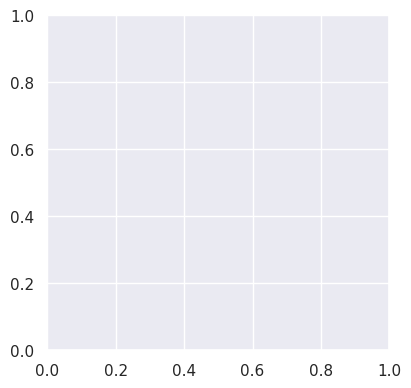

In [73]:
cols = df.select_dtypes(include=['integer', 'float']).columns.tolist()
cols.remove('default')
print(' With outliers','\n','*'*50)
show_boxplots(cols=cols, feature='default')

 Without outliers 
 **************************************************


TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

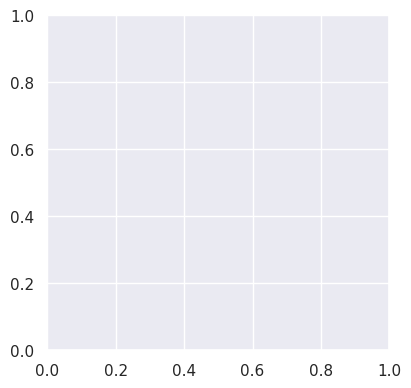

In [74]:
print(' Without outliers','\n','*'*50)
show_boxplots(cols=cols, feature='default', show_fliers=False)

## default vs loan_amnt

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

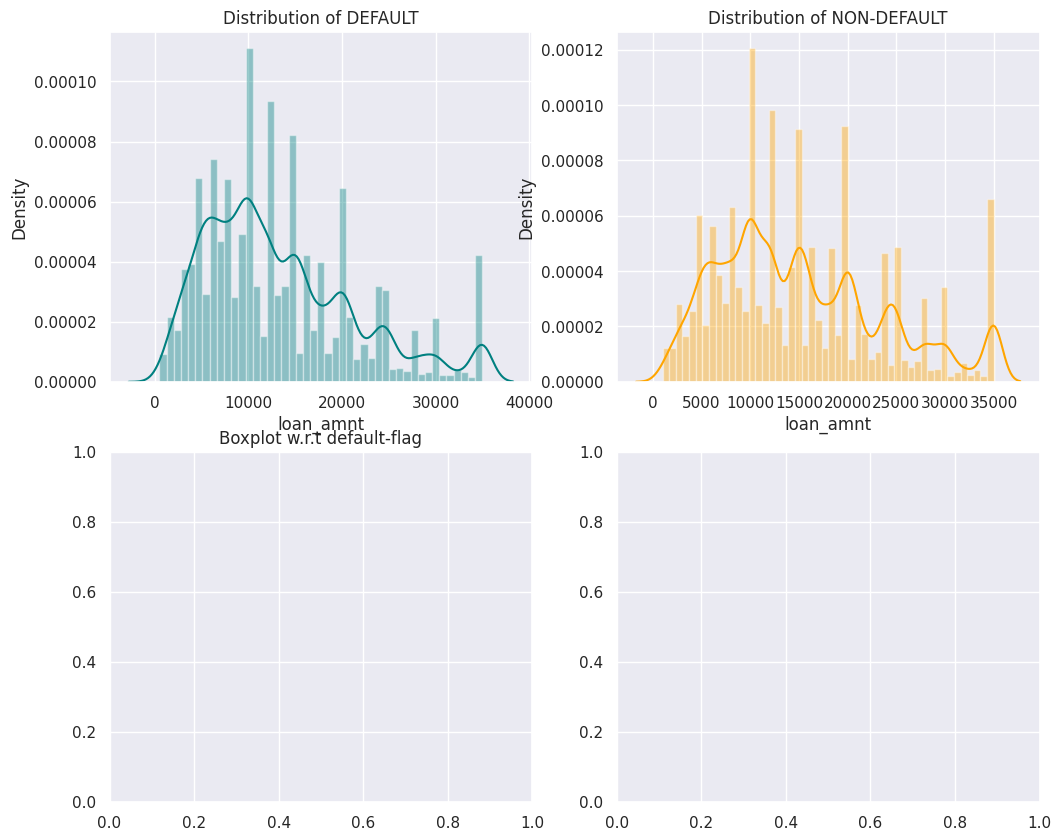

In [75]:
plot_target('loan_amnt')



## default vs interest_rate

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

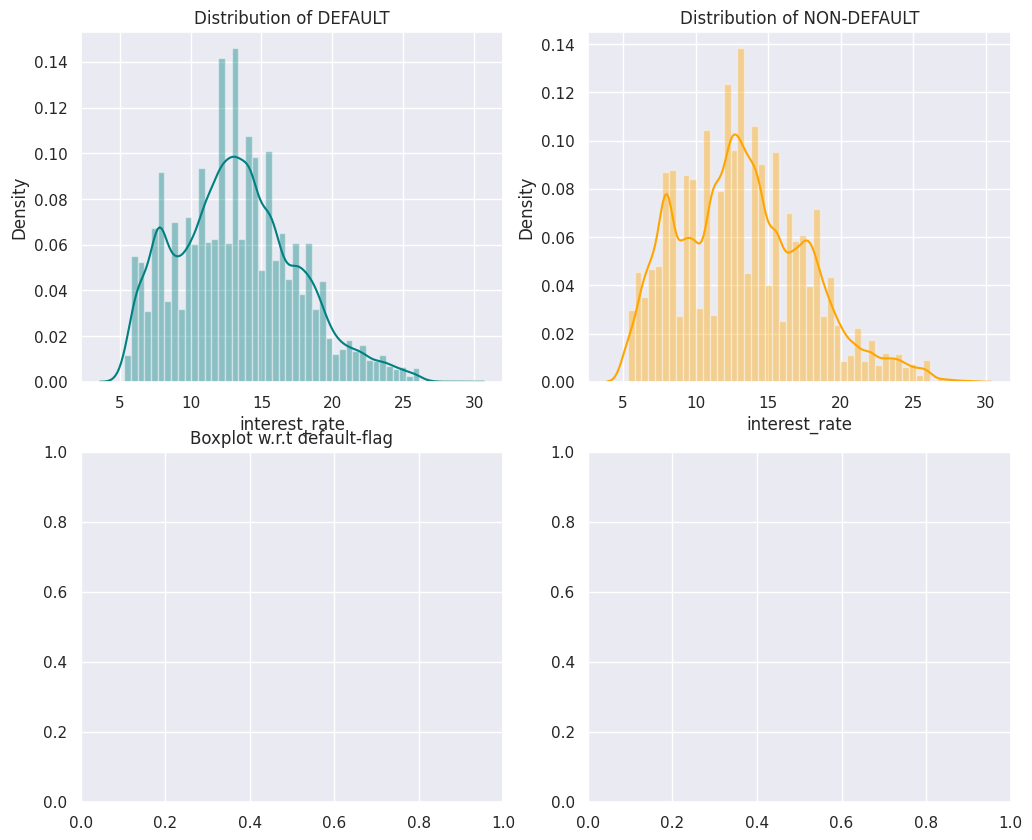

In [76]:
plot_target('interest_rate')

## default vs annual_income

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

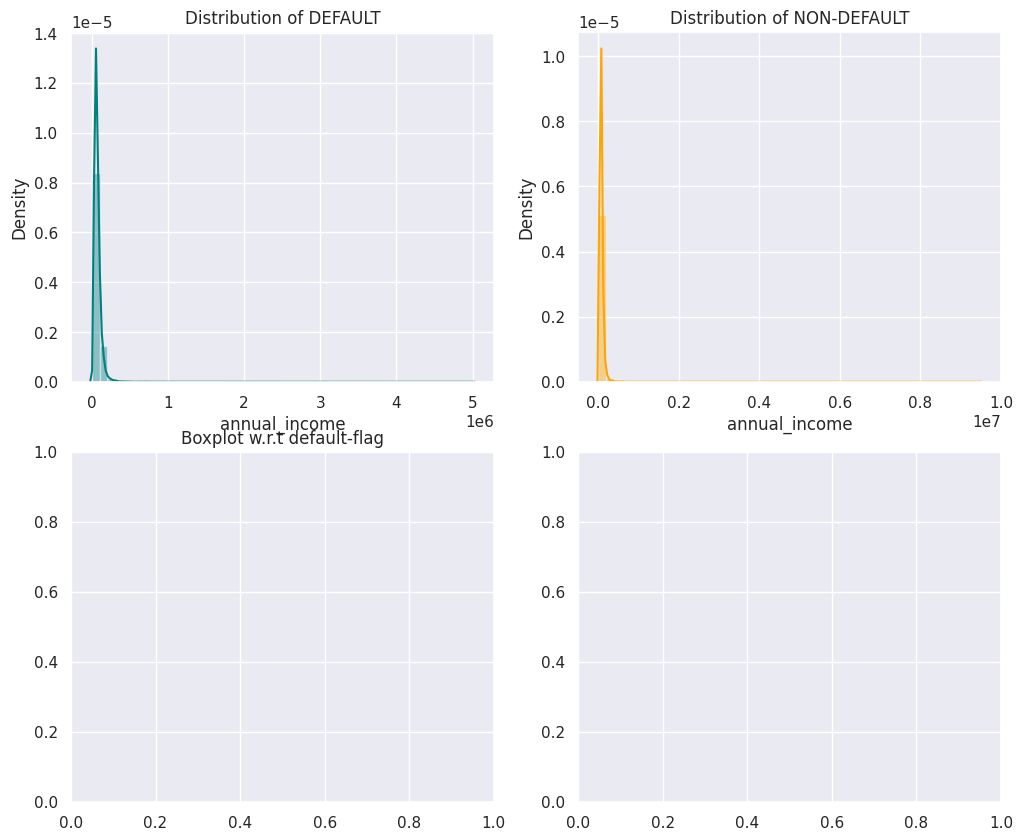

In [77]:
plot_target('annual_income')

## default vs debt_to_income

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

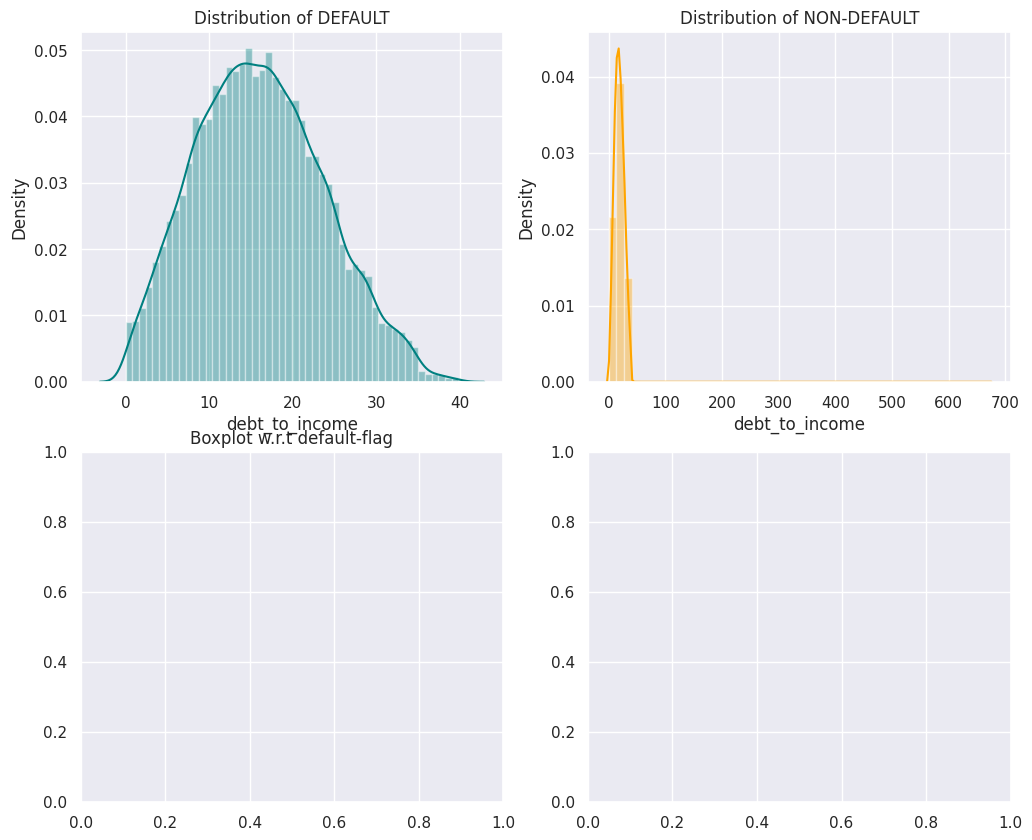

In [78]:
plot_target('debt_to_income')

## default vs delinq_2yrs

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

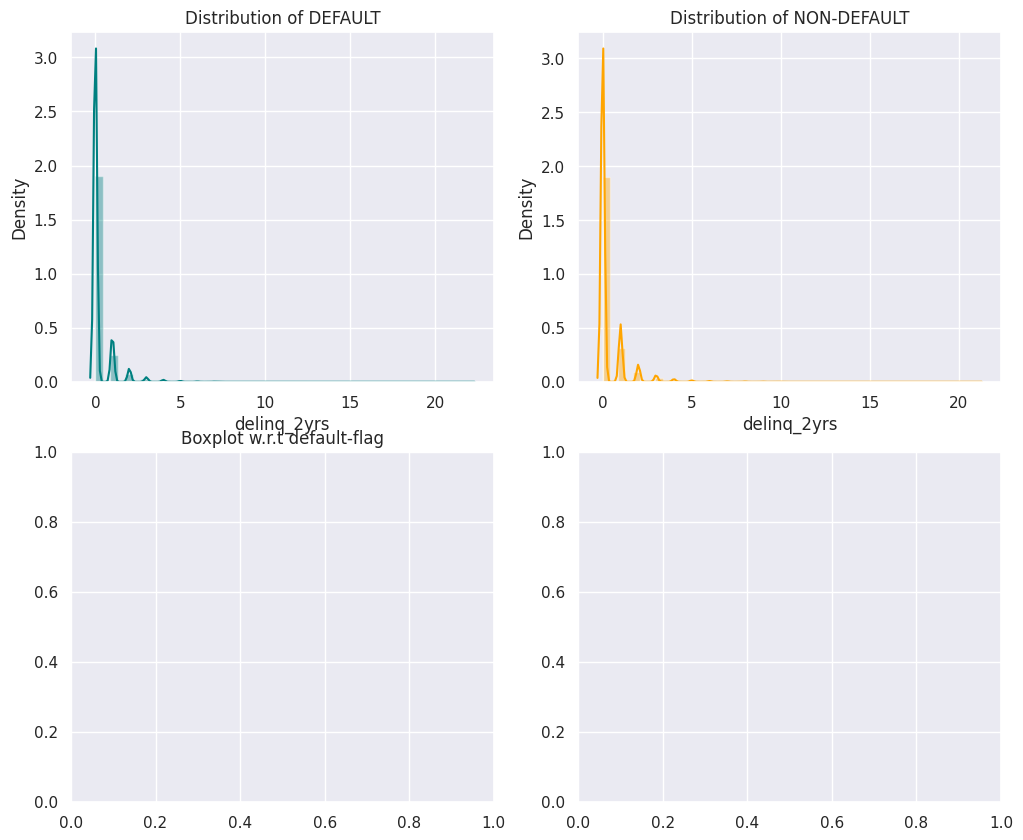

In [79]:
plot_target('delinq_2yrs')

## default vs public_records

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

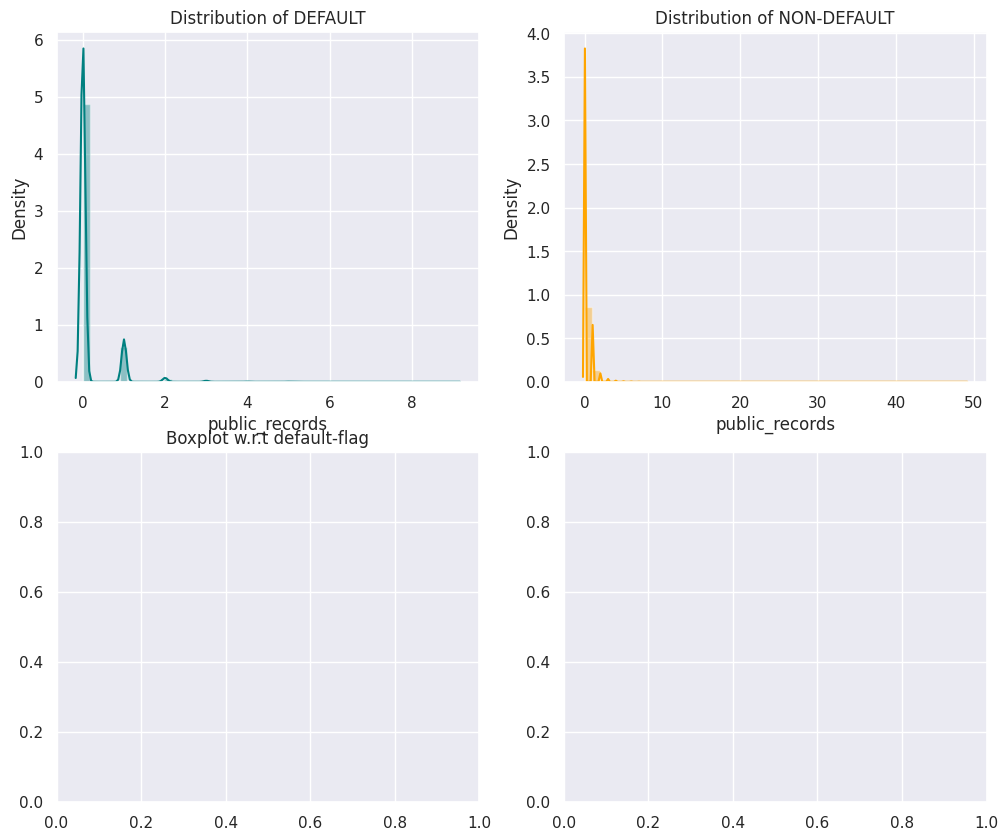

In [80]:
plot_target('public_records')

## default vs revolving_balance

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

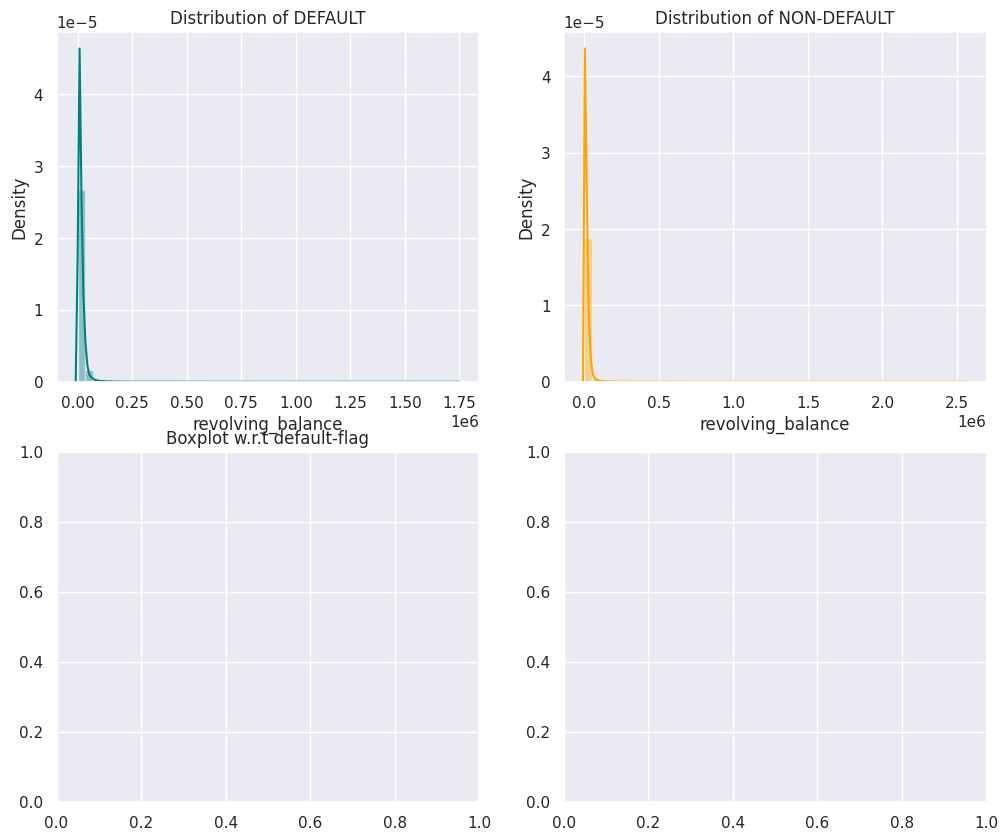

In [81]:
plot_target('revolving_balance')

## default vs total_acc

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

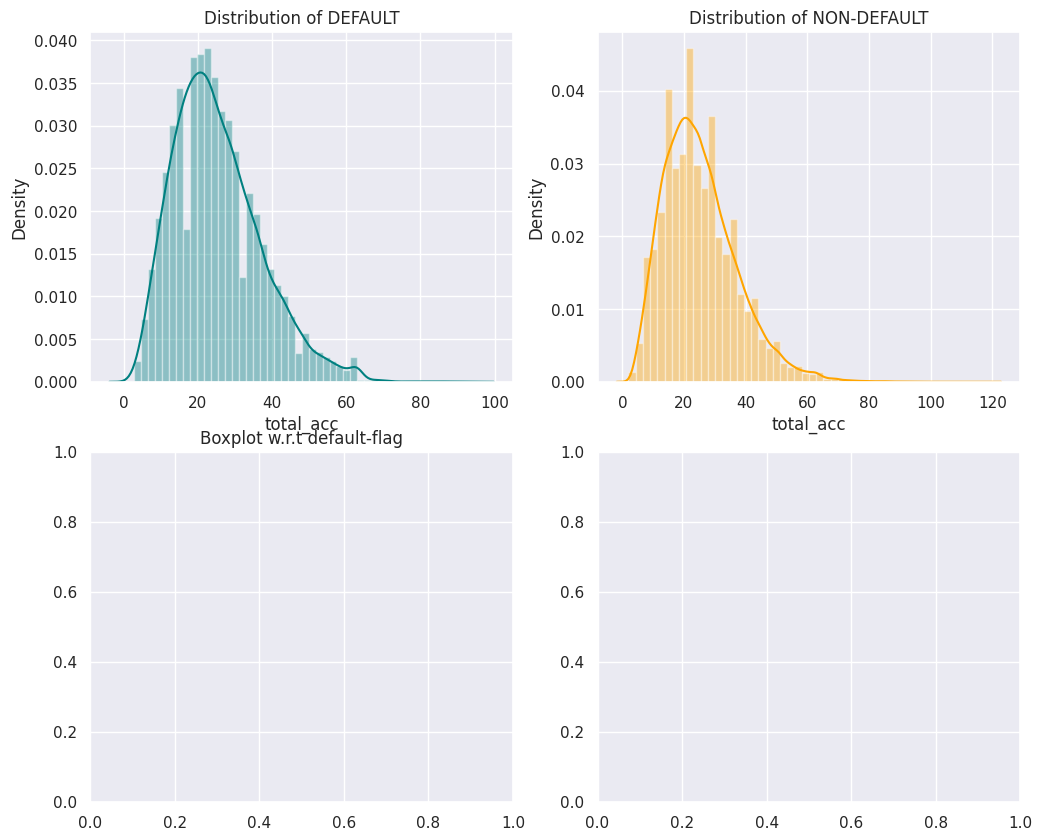

In [82]:
plot_target('total_acc')

## default vs interest_receive

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

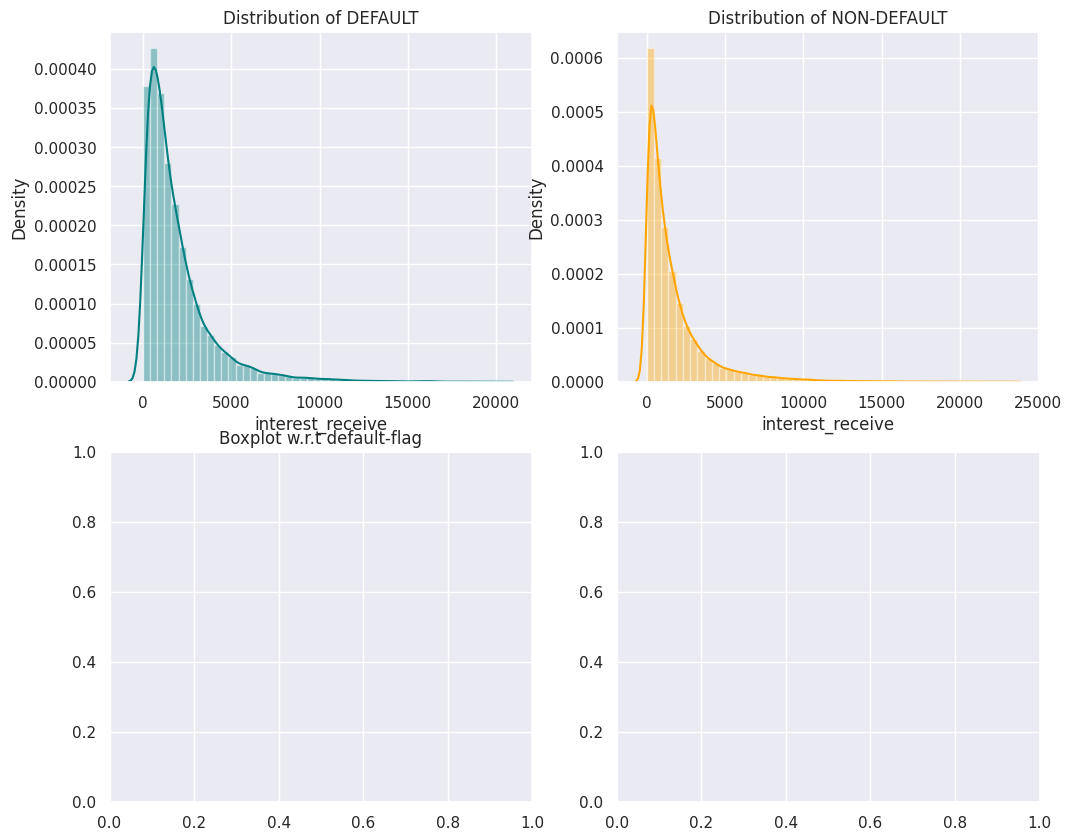

In [83]:
plot_target('interest_receive')

## default vs last_week_pay

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

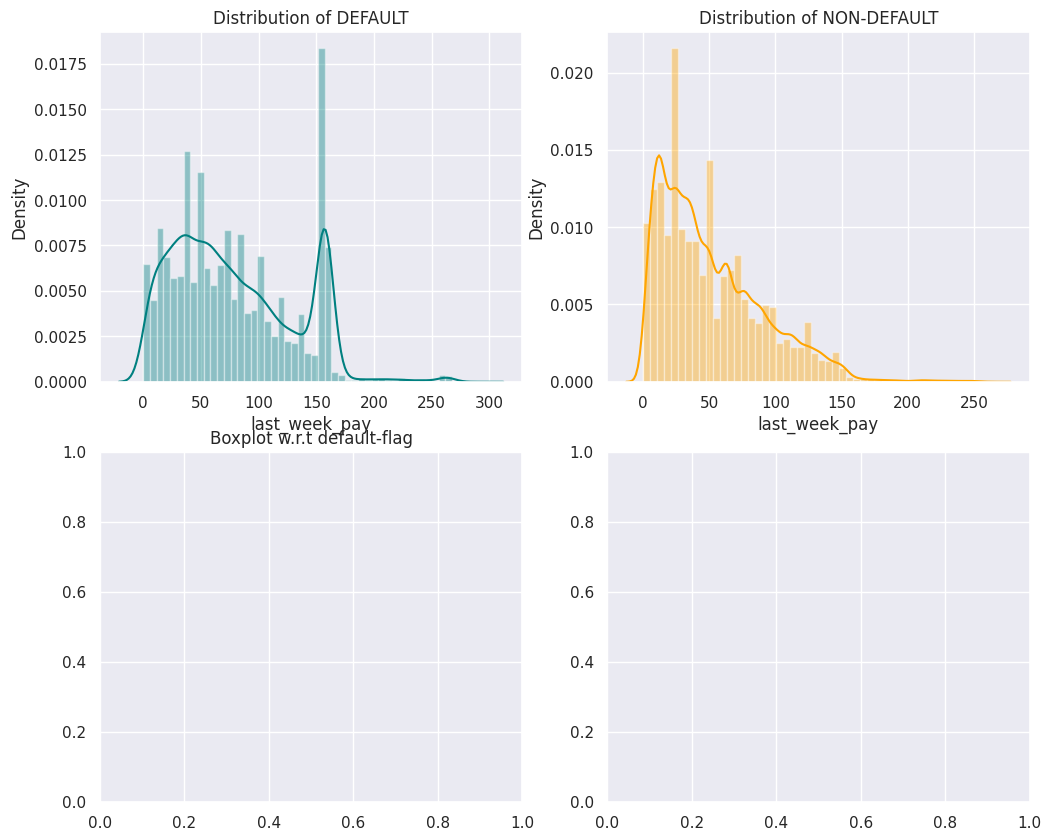

In [84]:
plot_target('last_week_pay')

## default vs total_current_balance

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

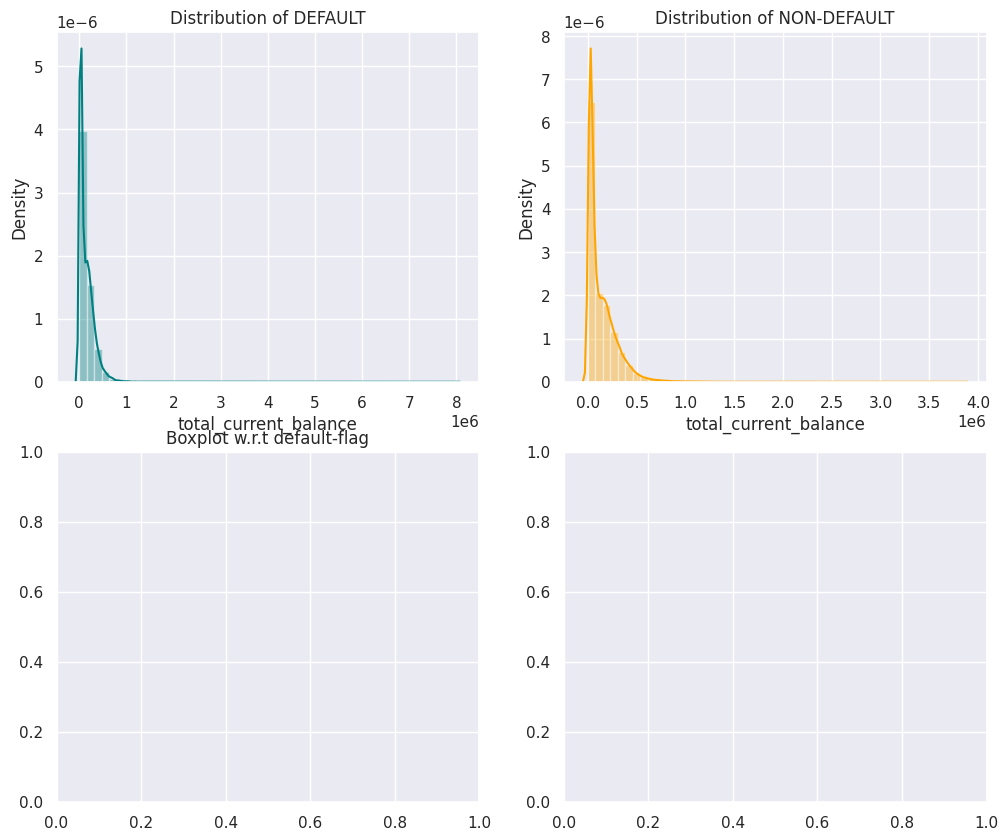

In [85]:
plot_target('total_current_balance')

## default vs total_revolving_limit

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

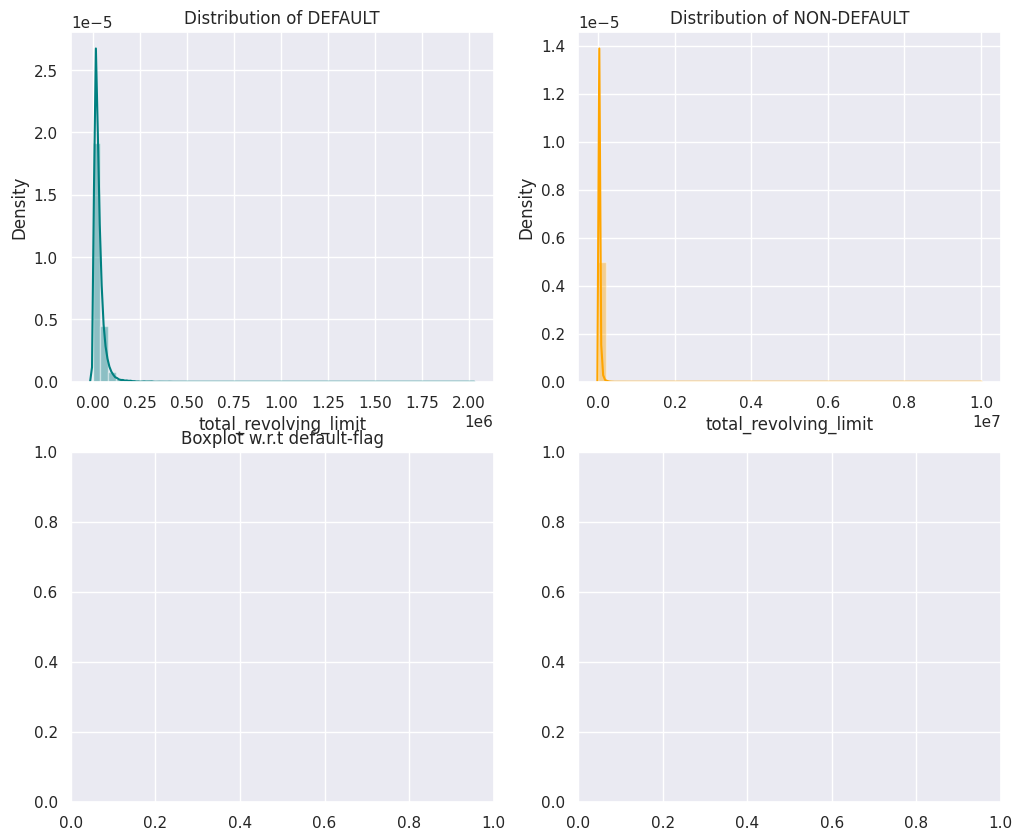

In [86]:
plot_target('total_revolving_limit')

In [ ]:
def show_violinplot(cols: list, feature: str, hue=df.default, data=df, show_fliers=True):
    #plt.figure(figsize=(12,10))
    for i, variable in enumerate(cols):
        plt.subplot(2, 2, i+1)
        sns.violinplot(data[feature],
                       data[variable],
                       hue=hue,
                       ci=0,
                       show_fliers=show_fliers)
        plt.tight_layout()
        plt.title(variable);

In [ ]:
cols = ['loan_amnt', 'interest_rate', 'total_acc', 'last_week_pay']
show_violinplot(cols, 'loan_term')

In [ ]:
show_violinplot(cols, 'loan_grade', show_fliers=False)

In [ ]:
show_violinplot(cols, 'job_experience', show_fliers=False)

In [ ]:
show_violinplot(cols, 'home_ownership', show_fliers=False)

In [ ]:
show_violinplot(cols, 'income_verification_status', show_fliers=False)

In [ ]:
show_violinplot(cols, 'loan_purpose', show_fliers=False)

In [90]:
Q1 = data.quantile(0.25) # To find the 25th percentile and 75th percentile.
Q3 = data.quantile(0.75)
IQR = Q3 - Q1            # Inter Quantile Range (75th perentile - 25th percentile)
lower = Q1-1.5 * IQR     # Finding lower and upper bounds for all values. All values outside these bounds are outliers
upper = Q3+1.5 * IQR
df_lower = (data.select_dtypes(include=['float64','int64']) < lower)
df_upper = (data.select_dtypes(include=['float64','int64']) > upper)
(df_lower | df_upper).sum()/len(data)*100

TypeError: unsupported operand type(s) for -: 'str' and 'str'

## Data Preparation

In [91]:
df.isnull().sum()

,0
loan_amnt,0
loan_term,0
interest_rate,0
loan_grade,0
loan_subgrade,0
job_experience,4702
home_ownership,0
annual_income,1
income_verification_status,0
loan_purpose,0


In [92]:
for i in df.select_dtypes(include=['category']).columns:
    print('Unique values in', i, 'are :')
    print(df[i].value_counts(dropna=False))
    print('*'*50)

Unique values in loan_term are :
loan_term
3 years    65211
5 years    27963
Name: count, dtype: int64
**************************************************
Unique values in loan_grade are :
loan_grade
B    26865
C    25787
A    15534
D    14715
E     7378
F     2344
G      551
Name: count, dtype: int64
**************************************************
Unique values in loan_subgrade are :
loan_subgrade
B4    5879
B3    5879
C2    5479
C1    5443
C3    5270
C4    5182
B2    5169
B5    5095
B1    4843
A5    4723
C5    4413
D1    3716
A4    3631
D2    3239
D3    2759
D4    2717
A3    2450
A1    2377
A2    2353
D5    2284
E1    1924
E2    1736
E3    1513
E4    1228
E5     977
F1     745
F2     545
F3     465
F4     355
F5     234
G1     174
G2     146
G3     105
G5      66
G4      60
Name: count, dtype: int64
**************************************************
Unique values in job_experience are :
job_experience
<5 Years      40610
10+ years     30362
6-10 years    17500
NaN            4702
N

In [93]:
# df1.home_ownership.replace('NONE','OTHER', inplace=True)
# df1.home_ownership.value_counts().sort_values(ascending=False)

In [94]:
# df1.income_verification_status.replace('Source Verified','Verified', inplace=True)
# df1.income_verification_status.value_counts().sort_values(ascending=False)

In [95]:
# df1['state_code'] = df1['state_code'].apply(region_combining)
# df1['state_code'] = df1['state_code'].astype('category')
# df1.state_code.value_counts(dropna=False)


In [96]:
#midwest = ['IA', 'IL', 'IN', 'KS', 'MI', 'MN', 'MO', 'ND', 'NE', 'OH', 'SD', 'WI']
#northeast = ['CT', 'MA', 'ME', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT']
#south = ['AL', 'AR', 'DC', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK',
#         'SC', 'TN', 'TX', 'VA', 'WV']
#west = ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NM', 'NV', 'OR', 'UT', 'WA', 'WY']

## Missing value treatment

In [97]:
df1 = df.copy()

In [ ]:
df1.annual_income.fillna(df.annual_income.mean(), inplace=True)
df1.last_week_pay.fillna(df.last_week_pay.mean(), inplace=True)
df1.total_current_balance.fillna(df.total_current_balance.mean(), inplace=True)
df1.total_revolving_limit.fillna(df.total_revolving_limit.mean(), inplace=True)
df1.total_acc.fillna(df.total_acc.mean(), inplace=True)

In [98]:
job_experience = {'<5 Years':0, '6-10 years':1, '10+ years':2}
df1['job_experience'] = df1['job_experience'].map(job_experience).astype('Int32')

loan_term = {'3 years': 0, '5 years': 1}
df1['loan_term'] = df1['loan_term'].map(loan_term).astype('Int32')

loan_grade = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
df1['loan_grade'] = df1['loan_grade'].map(loan_grade).astype('Int32')

loan_subgrade = {'A1':0,  'A2':1,  'A3':2,  'A4':3,  'A5':4,
                 'B1':5,  'B2':6,  'B3':7,  'B4':8,  'B5':9,
                 'C1':10, 'C2':11, 'C3':12, 'C4':13, 'C5':14,
                 'D1':15, 'D2':16, 'D3':17, 'D4':18, 'D5':19,
                 'E1':20, 'E2':21, 'E3':22, 'E4':23, 'E5':24,
                 'F1':25, 'F2':26, 'F3':27, 'F4':28, 'F5':29,
                 'G1':30, 'G2':31, 'G3':32, 'G4':33, 'G5':34}
df1['loan_subgrade'] = df1['loan_subgrade'].map(loan_subgrade).astype('Int32')

home_ownership = {'MORTGAGE':0, 'RENT':1, 'OWN':2, 'OTHER':3, 'NONE':4}
df1['home_ownership'] = df1['home_ownership'].map(home_ownership).astype('Int32')

income_verification_status = {'Verified':0, 'Not Verified':1, 'Source Verified':2}
df1['income_verification_status'] = df1['income_verification_status'].map(income_verification_status).astype('Int32')

loan_purpose = {'debt_consolidation': 0, 'credit_card':1, 'home_improvement': 2, 'other': 3}
df1['loan_purpose'] = df1['loan_purpose'].map(loan_purpose).astype('Int32')

application_type = {'INDIVIDUAL': 0, 'JOINT':1}
df1['application_type'] = df1['application_type'].map(application_type).astype('Int32')

state_code = {'AK':0,  'AL':1,  'AR':2,  'AZ':3,  'CA':4 , 'CO':5,  'CT':6,  'DC':7,  'DE':8,
              'FL':9,  'GA':10, 'HI':11, 'IA':12, 'ID':13, 'IL':14, 'IN':15, 'KS':16, 'KY':17,
              'LA':18, 'MA':19, 'MD':20, 'ME':21, 'MI':22, 'MN':23, 'MO':24, 'MS':25, 'MT':26,
              'NC':27, 'ND':28, 'NE':29, 'NH':30, 'NJ':31, 'NM':32, 'NV':33, 'NY':34, 'OH':35,
              'OK':36, 'OR':37, 'PA':38, 'RI':39, 'SC':40, 'SD':41, 'TN':42, 'TX':43, 'UT':44,
              'VA':45, 'VT':46, 'WA':47, 'WI':48, 'WV':49, 'WY':50}
df1['state_code'] = df1['state_code'].map(state_code).astype('Int32')

In [99]:
df1.head()

,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,loan_purpose,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
0,9000,0,9.170,1,6,0,2,85000.000,1,0,...,0.000,0.000,39519,20.000,59.600,0,4.000,95493.000,84100.000,0
1,18000,0,13.650,2,10,0,2,64000.000,0,0,...,0.000,1.000,9783,24.000,3348.250,0,95.000,185433.000,13500.000,0
2,16000,0,7.260,0,3,0,0,150000.000,2,0,...,2.000,0.000,13641,27.000,276.690,0,13.000,180519.000,19300.000,0
3,25000,0,13.990,2,13,<NA>,0,59800.000,0,0,...,0.000,0.000,35020,35.000,1106.720,0,17.000,183208.000,55400.000,0
4,17000,0,6.390,0,1,2,0,72000.000,2,1,...,0.000,0.000,23990,26.000,725.290,0,39.000,23990.000,81300.000,0


In [100]:
imputer = KNNImputer(n_neighbors=5)

In [ ]:
X = df1.drop(['default'], axis=1)
y = df1.drop['default']

In [102]:
# Fixed and complete example for splitting data into train and test sets

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [103]:
df.dropna(how='all')

,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,loan_purpose,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
0,9000,3 years,9.170,B,B2,<5 Years,OWN,85000.000,Not Verified,debt_consolidation,...,0.000,0.000,39519,20.000,59.600,INDIVIDUAL,4.000,95493.000,84100.000,0
1,18000,3 years,13.650,C,C1,<5 Years,OWN,64000.000,Verified,debt_consolidation,...,0.000,1.000,9783,24.000,3348.250,INDIVIDUAL,95.000,185433.000,13500.000,0
2,16000,3 years,7.260,A,A4,<5 Years,MORTGAGE,150000.000,Source Verified,debt_consolidation,...,2.000,0.000,13641,27.000,276.690,INDIVIDUAL,13.000,180519.000,19300.000,0
3,25000,3 years,13.990,C,C4,NaN,MORTGAGE,59800.000,Verified,debt_consolidation,...,0.000,0.000,35020,35.000,1106.720,INDIVIDUAL,17.000,183208.000,55400.000,0
4,17000,3 years,6.390,A,A2,10+ years,MORTGAGE,72000.000,Source Verified,credit_card,...,0.000,0.000,23990,26.000,725.290,INDIVIDUAL,39.000,23990.000,81300.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93169,3200,3 years,7.260,A,A4,<5 Years,RENT,85000.000,Not Verified,debt_consolidation,...,0.000,0.000,7924,38.000,55.340,INDIVIDUAL,13.000,64635.000,47600.000,0
93170,3500,3 years,5.420,A,A1,NaN,MORTGAGE,57550.000,Not Verified,other,...,0.000,0.000,10174,24.000,299.670,INDIVIDUAL,161.000,NaN,NaN,1
93171,8000,3 years,13.980,C,C3,10+ years,RENT,148531.500,Source Verified,credit_card,...,1.000,0.000,5391,25.000,1150.580,INDIVIDUAL,65.000,94596.000,6500.000,0
93172,35000,3 years,17.770,D,D1,<5 Years,RENT,100000.000,Verified,debt_consolidation,...,0.000,0.000,24609,45.000,5764.580,INDIVIDUAL,56.000,33759.000,34900.000,1


In [104]:
to_drop = ["Interest_Received","Application_Types","Last_week_pay","Total_Current_Balance","Total_revolving_limit","Default"]


In [105]:
to_drop = ["Interest_Received","Application_Types","Last_week_pay","Total_Current_Balance","Total_revolving_limit","Default"]
to_drop_2 = ["Interest Received", "Application Type"]

In [106]:
df.dropna()

,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,loan_purpose,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
0,9000,3 years,9.170,B,B2,<5 Years,OWN,85000.000,Not Verified,debt_consolidation,...,0.000,0.000,39519,20.000,59.600,INDIVIDUAL,4.000,95493.000,84100.000,0
1,18000,3 years,13.650,C,C1,<5 Years,OWN,64000.000,Verified,debt_consolidation,...,0.000,1.000,9783,24.000,3348.250,INDIVIDUAL,95.000,185433.000,13500.000,0
2,16000,3 years,7.260,A,A4,<5 Years,MORTGAGE,150000.000,Source Verified,debt_consolidation,...,2.000,0.000,13641,27.000,276.690,INDIVIDUAL,13.000,180519.000,19300.000,0
4,17000,3 years,6.390,A,A2,10+ years,MORTGAGE,72000.000,Source Verified,credit_card,...,0.000,0.000,23990,26.000,725.290,INDIVIDUAL,39.000,23990.000,81300.000,0
5,10000,3 years,12.690,C,C2,<5 Years,OWN,56000.000,Not Verified,debt_consolidation,...,0.000,1.000,6643,48.000,590.500,INDIVIDUAL,26.000,24054.000,25167.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93168,23850,5 years,21.000,E,E2,10+ years,MORTGAGE,90000.000,Verified,home_improvement,...,0.000,1.000,9954,10.000,10977.490,INDIVIDUAL,139.000,74395.000,12200.000,0
93169,3200,3 years,7.260,A,A4,<5 Years,RENT,85000.000,Not Verified,debt_consolidation,...,0.000,0.000,7924,38.000,55.340,INDIVIDUAL,13.000,64635.000,47600.000,0
93171,8000,3 years,13.980,C,C3,10+ years,RENT,148531.500,Source Verified,credit_card,...,1.000,0.000,5391,25.000,1150.580,INDIVIDUAL,65.000,94596.000,6500.000,0
93172,35000,3 years,17.770,D,D1,<5 Years,RENT,100000.000,Verified,debt_consolidation,...,0.000,0.000,24609,45.000,5764.580,INDIVIDUAL,56.000,33759.000,34900.000,1


In [107]:
data.isnull().sum()

,0
ID,0
loan_amnt,0
loan_term,0
interest_rate,0
loan_grade,0
loan_subgrade,0
job_experience,4702
home_ownership,0
annual_income,1
income_verification_status,0


In [108]:
import pandas as pd
import numpy as np

data = {'ID': ['Job experience','Interest_received','Application_Type','Last_week_pay','Total_current_balance','Total_revolving_balance'],'NaN':[3429,1,1,1380,5360,5360]}
df = pd.DataFrame(data)

df_clean = df.dropna(subset=['ID','NaN'])
print(df_clean)

                        ID   NaN
0           Job experience  3429
1        Interest_received     1
2         Application_Type     1
3            Last_week_pay  1380
4    Total_current_balance  5360
5  Total_revolving_balance  5360


In [ ]:
df.dropna()

In [109]:
import numpy as np
from sklearn.model_selection import train_test_split

# Sample data
X, y = np.arange(10).reshape((5, 2)), range(5)

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [110]:
# Splitting data into training and test set using your actual processed dataset (df1):
# Make sure df1 has been defined and loaded correctly first.
try:
    X = df1.drop(['default'], axis=1)
    y = df1['default']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7, stratify=y)
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
except NameError:
    print("NameError: Please make sure 'df1' is defined and has no missing values in the target column before running this split.")

Train shape: (65221, 21) Test shape: (27953, 21)


In [119]:
#Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

In [120]:
#Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test),columns=X_test.columns)

In [111]:
#Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

In [121]:
#Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print('-'*30)
print(X_test.isna().sum())

loan_amnt                     0
loan_term                     0
interest_rate                 0
loan_grade                    0
loan_subgrade                 0
job_experience                0
home_ownership                0
annual_income                 0
income_verification_status    0
loan_purpose                  0
state_code                    0
debt_to_income                0
delinq_2yrs                   0
public_records                0
revolving_balance             0
total_acc                     0
interest_receive              0
application_type              0
last_week_pay                 0
total_current_balance         0
total_revolving_limit         0
dtype: int64
------------------------------
loan_amnt                     0
loan_term                     0
interest_rate                 0
loan_grade                    0
loan_subgrade                 0
job_experience                0
home_ownership                0
annual_income                 0
income_verification_status  

In [122]:
## Function to inverse the encoding
def inverse_mapping(x,y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype('category')
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype('category')

In [124]:
cols = X_train.select_dtypes(include=['object','category'])
for i in cols.columns:
    print(X_train[i].value_counts(dropna=False))
    print('*'*30)

loan_term
3 years    45758
5 years    19463
Name: count, dtype: int64
******************************
loan_grade
B    18860
C    18022
A    10937
D    10225
E     5182
F     1624
G      371
Name: count, dtype: int64
******************************
job_experience
<5 Years      29942
10+ years     21309
6-10 years    13970
Name: count, dtype: int64
******************************
home_ownership
MORTGAGE    32466
RENT        26216
OWN          6526
OTHER          11
NONE            2
Name: count, dtype: int64
******************************
income_verification_status
Source Verified    24162
Verified           21404
Not Verified       19655
Name: count, dtype: int64
******************************
loan_purpose
debt_consolidation    38711
credit_card           15058
other                  7656
home_improvement       3796
Name: count, dtype: int64
******************************
application_type
INDIVIDUAL    65188
JOINT            33
Name: count, dtype: int64
******************************


## Encoding categorical variables

In [125]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_test.shape)

(65221, 33) (27953, 33)


In [126]:
X_train.columns

Index(['loan_amnt', 'interest_rate', 'loan_subgrade', 'annual_income',
       'state_code', 'debt_to_income', 'delinq_2yrs', 'public_records',
       'revolving_balance', 'total_acc', 'interest_receive', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit', 'loan_term_5 years',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G', 'job_experience_6-10 years',
       'job_experience_<5 Years', 'home_ownership_NONE',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'income_verification_status_Source Verified',
       'income_verification_status_Verified',
       'loan_purpose_debt_consolidation', 'loan_purpose_home_improvement',
       'loan_purpose_other', 'application_type_JOINT'],
      dtype='object')

## Model Building

In [127]:
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model, flag=True):
    '''
    model : classifier to predict values of X
    flag: Flag to print metric score dataframe. (default=True)
    '''
    # defining an empty list to store train and test results
    scores = []
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    train_f1 = f1_score(y_train,pred_train)
    test_f1 = f1_score(y_test,pred_test)
    scores.extend(
        (
            train_acc, test_acc,
            train_recall, test_recall,
            train_precision, test_precision,
            train_f1, test_f1
        )
    )

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        metric_names = [
            'Train Accuracy', 'Test Accuracy', 'Train Recall', 'Test Recall',
            'Train Precision', 'Test Precision', 'Train F1-Score', 'Test F1-Score'
        ]
        cols = ['Metric', 'Score']
        records = [(name, score) for name, score in zip(metric_names, scores)]
        display(pd.DataFrame.from_records(records, columns=cols, index='Metric').T)

    return scores # returning the list with train and test scores

In [128]:
## Function to create confusion matrix
def make_confusion_matrix(model,  y_actual, labels=[1, 0], xtest=X_test):
    """
    model : classifier to predict values of X
    y_actual : ground truth
    """
    y_predict = model.predict(xtest)
    cm = metrics.confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Yes", "No"], columns=["Yes", "No"])

    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten()/np.sum(cm)]

    labels = [f"{gc}\n{gp}" for gc, gp in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize = (10, 7))
    sns.heatmap(df_cm, annot=labels, fmt='')
    plt.ylabel("Actual", fontsize=14)
    plt.xlabel("Predicted", fontsize=14);

In [129]:
def show_model_performance(model: list, model_names: list):
    results = []
    for model, name in zip(models, model_names):
        (acc_train, acc_test,
         recall_train, recall_test,
         precision_train, precision_test,
         f1_train, f1_test) = get_metrics_score(model, False)

        results.append((name, acc_train, acc_test, recall_train, recall_test,
                    precision_train, precision_test, f1_train, f1_test))

    cols = [
        'Model', 'Train Acc', 'Test Accuracy', 'Train Recall',
        'Test Recall', 'Train Precision', 'Test Precision',
        'Train F1-Score', 'Test F1-Score'
    ]

    comparison_frame = pd.DataFrame.from_records(results, columns=cols, index='Model')
    # Sorting models in decreasing order of test f1-score
    display(comparison_frame.sort_values(by='Test F1-Score', ascending=False))



## Cross Validation Scores

In [130]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train, y_train)

LogisticRegression(random_state=1)

In [131]:
LogisticRegression(random_state=1)

LogisticRegression(random_state=1)

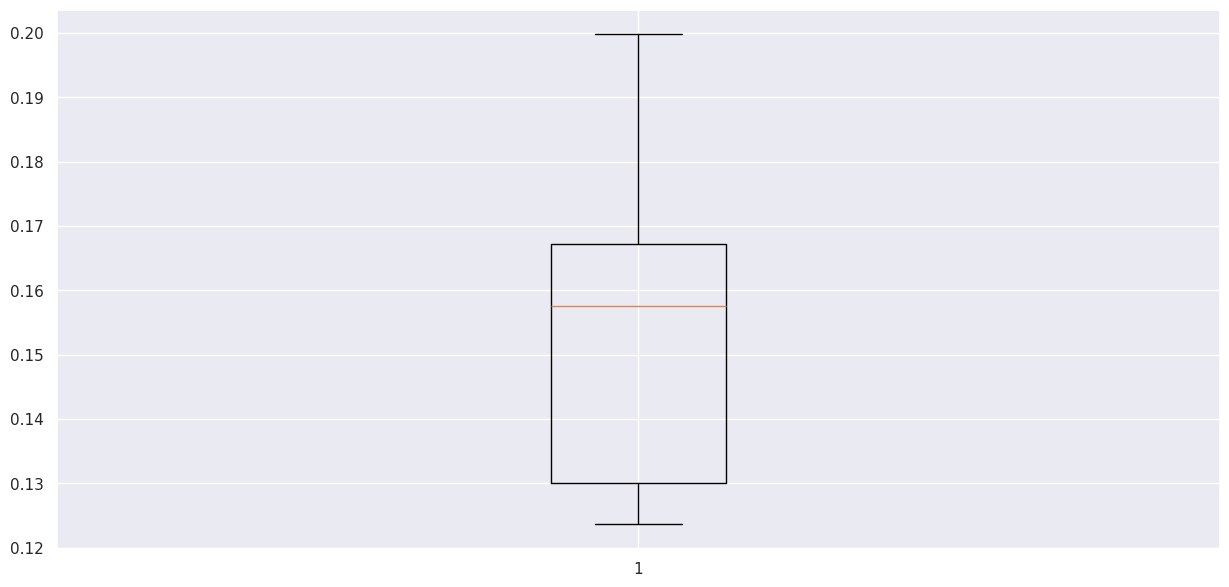

In [132]:
scoring = 'recall'
#Setting number of splits equal to 5
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_result_bfr = cross_val_score(estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold)
#Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_bfr);

Metric,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
Score,0.772,0.775,0.193,0.195,0.559,0.579,0.287,0.292


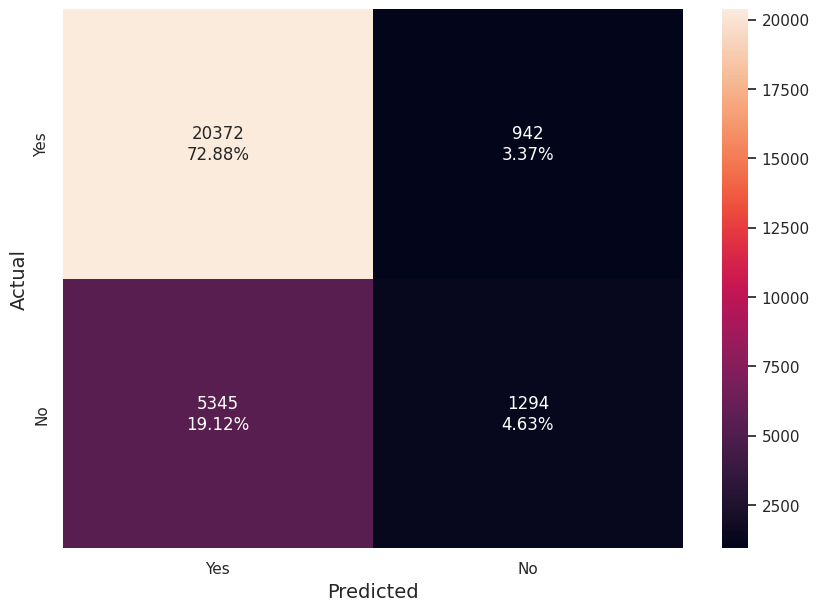

In [133]:
get_metrics_score(lr)
make_confusion_matrix(lr, y_test)

## Oversampling train data

In [134]:
from imblearn.over_sampling import SMOTE

print("Before UpSampling, counts of label 'Yes': {}".format(sum(y_train==1)))
print("Before UpSampling, counts of label 'No': {} \n".format(sum(y_train==0)))

sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5, random_state=1)   #Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_over==1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_over==0)))

print('After UpSampling, the shape of train_X: {}'.format(X_train_over.shape))
print('After UpSampling, the shape of train_y: {} \n'.format(y_train_over.shape))

Before UpSampling, counts of label 'Yes': 15490
Before UpSampling, counts of label 'No': 49731 

After UpSampling, counts of label 'Yes': 49731
After UpSampling, counts of label 'No': 49731 

After UpSampling, the shape of train_X: (99462, 33)
After UpSampling, the shape of train_y: (99462,) 



In [135]:
log_reg_over = LogisticRegression(random_state=1)

# Training the basic logistic regression model with the training set
log_reg_over.fit(X_train_over, y_train_over)

LogisticRegression(random_state=1)

In [136]:
LogisticRegression(random_state=1)

LogisticRegression(random_state=1)

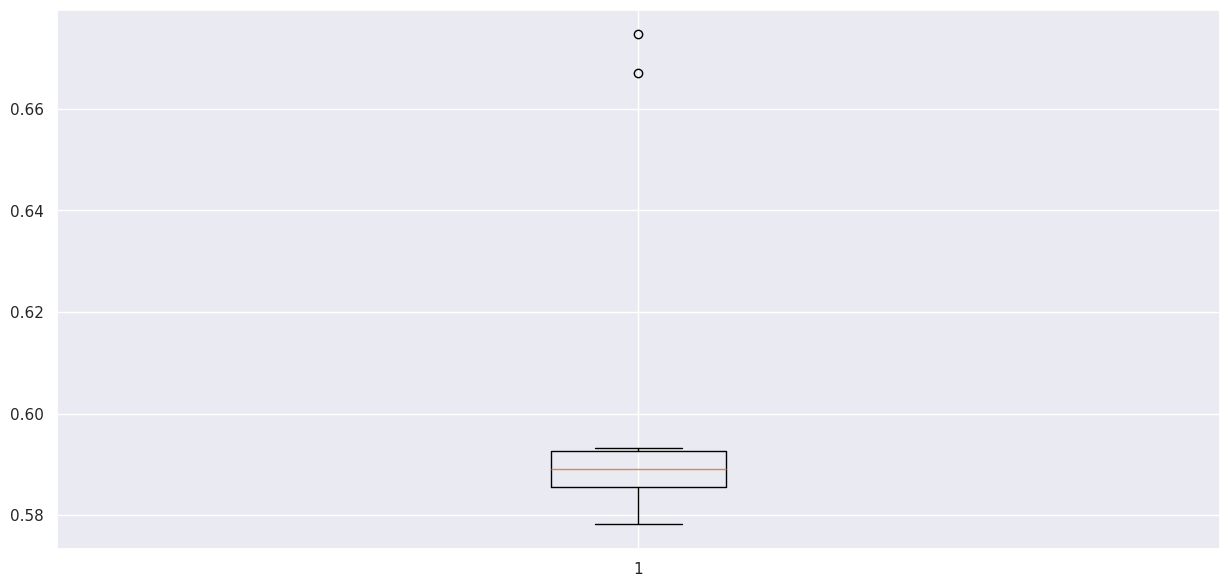

In [137]:
scoring = 'recall'
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)     #Setting number of splits equal to 5
cv_result_over = cross_val_score(estimator=log_reg_over, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold)
#Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_over);

Metric,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
Score,0.649,0.658,0.555,0.555,0.350,0.358,0.429,0.435


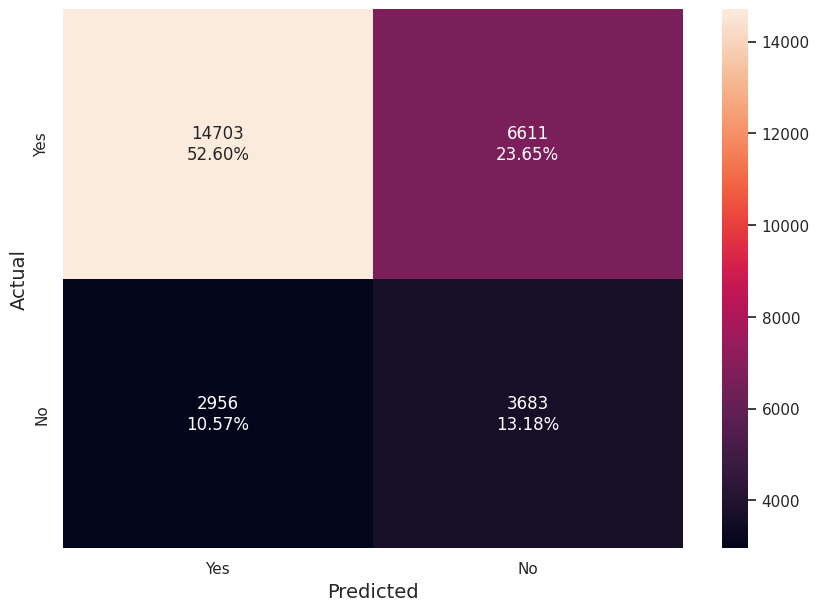

In [138]:
get_metrics_score(log_reg_over)
make_confusion_matrix(log_reg_over, y_test)

## Regularization

In [139]:
# Choose the type of classifier.
lr_estimator = LogisticRegression(random_state=1)

# Grid of parameters to choose from
parameters = {'C': np.arange(0.1, 1.1, 0.1)}

# Run the grid search
grid_obj = GridSearchCV(lr_estimator, parameters, scoring='recall', n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
lr_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
lr_estimator.fit(X_train_over, y_train_over)

LogisticRegression(C=np.float64(1.0), random_state=1)

In [140]:
LogisticRegression(C=0.4, random_state=1)

LogisticRegression(C=0.4, random_state=1)

Metric,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
Score,0.649,0.658,0.555,0.555,0.350,0.358,0.429,0.435


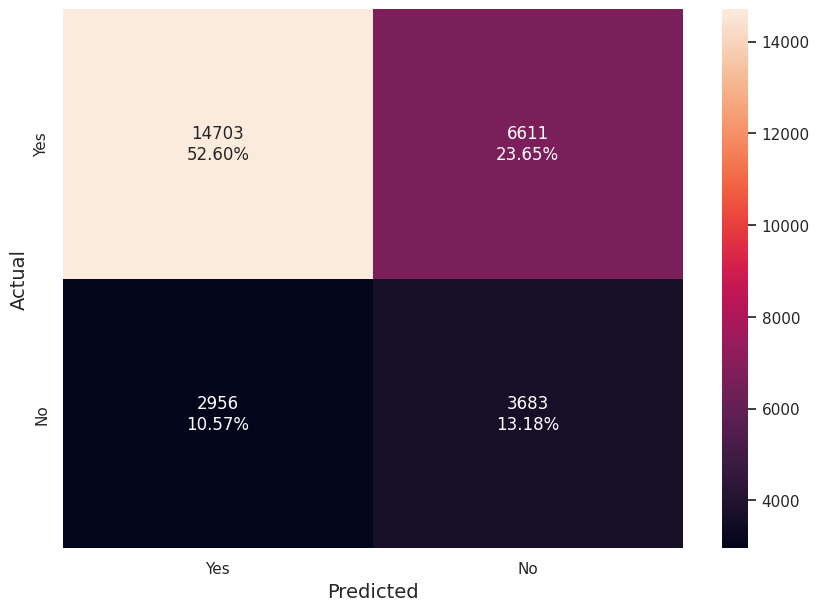

In [141]:
get_metrics_score(lr_estimator)
make_confusion_matrix(lr_estimator, y_test)

In [142]:
models = []  # Empty list to store all the models

# Appending pipelines for each model into the list

models.append(
    (
        "DTREE",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("decision_tree", DecisionTreeClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "BAGGING",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("random_forest", BaggingClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "RF",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("random_forest", RandomForestClassifier(random_state=1)),
            ]
        ),
    )
)

models.append(
    (
        "ADB",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("adaboost", AdaBoostClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "GBM",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("gradient_boosting", GradientBoostingClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "XGB",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("xgboost", XGBClassifier(random_state=1, eval_metric='logloss')),
            ]
        ),
    )
)

results = []  # Empty list to store all model's CV scores
names = []   # Empty list to store name of the models

# loop through all models to get the mean cross validated score
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold)
    results.append(cv_result)
    names.append(name)

    print(f"{name}: {cv_result.mean() * 100}")


DTREE: 53.71207230471272
BAGGING: 41.25242091672046
RF: 23.466752743705616
ADB: 16.042608134280183
GBM: 21.3557133634603
XGB: 55.94577146546158


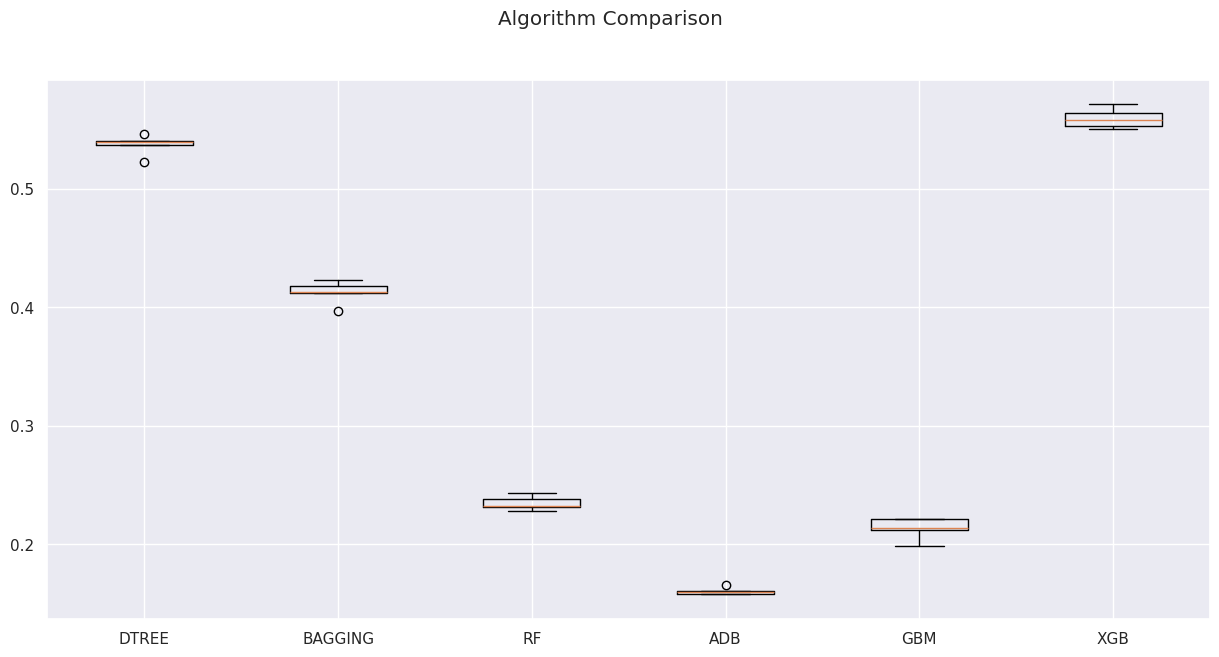

In [143]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(15, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names);

## XGBoost Classifier

## Hyperparameter Tuning using RandomizedSearchCV

In [144]:
%%time

#Creating pipeline
pipe=make_pipeline(StandardScaler(),XGBClassifier(random_state=1,eval_metric='logloss', n_estimators=50))

#Parameter grid to pass in RandomizedSearchCV
param_grid={'xgbclassifier__n_estimators':np.arange(50,300,50),
            'xgbclassifier__scale_pos_weight':[0,1,2,5,10],
            'xgbclassifier__learning_rate':[0.01,0.1,0.2,0.05],
            'xgbclassifier__gamma':[0,1,3,5],
            'xgbclassifier__subsample':[0.7,0.8,0.9,1],
            'xgbclassifier__max_depth':np.arange(1,10,1),
            'xgbclassifier__reg_lambda':[0,1,2,5,10]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_iter=50,
                                   scoring=scorer, cv=5, random_state=1, n_jobs=-1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print(f"Best Parameters:{randomized_cv.best_params_} \nScore: {randomized_cv.best_score_}")

Best Parameters:{'xgbclassifier__subsample': 1, 'xgbclassifier__scale_pos_weight': 2, 'xgbclassifier__reg_lambda': 2, 'xgbclassifier__n_estimators': np.int64(150), 'xgbclassifier__max_depth': np.int64(7), 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__gamma': 0} 
Score: 0.703397360428425
CPU times: user 4.11 s, sys: 328 ms, total: 4.44 s
Wall time: 3min 23s


Metric,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
Score,0.899,0.867,0.758,0.671,0.806,0.743,0.782,0.705


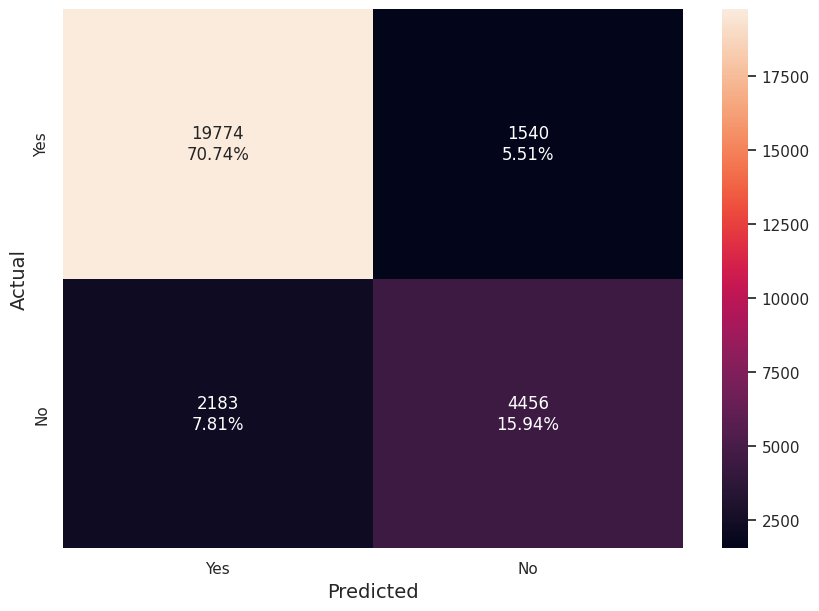

In [145]:
# Creating new pipeline with best parameters
xgb_tuned = make_pipeline(
    StandardScaler(),
    XGBClassifier(
        random_state=1,
        n_estimators=150,
        scale_pos_weight=2,
        reg_lambda=2,
        max_depth=7,
        subsample=1,
        learning_rate=0.1,
        gamma=0,
        eval_metric='logloss',
        n_jobs=-1
    )
)

# Fit the model on training data
xgb_tuned.fit(X_train, y_train)

#Calculating different metrics
get_metrics_score(xgb_tuned)

#Creating confusion matrix
make_confusion_matrix(xgb_tuned, y_test)

## Bagging Classifier

## Hyperparameter tuning using GridSearchCV

In [150]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), BaggingClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV
param_grid = {
    'baggingclassifier__max_samples':  [0.7, 0.8, 0.9, 1],
    'baggingclassifier__max_features': [0.7, 0.8, 0.9, 1],
    'baggingclassifier__n_estimators': [30, 40, 50, 70]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs=-1)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(f"Best Parameters:{grid_cv.best_params_} \nScore: {grid_cv.best_score_}")

Best Parameters:{'baggingclassifier__max_features': 0.9, 'baggingclassifier__max_samples': 0.9, 'baggingclassifier__n_estimators': 50} 
Score: 0.5390613818165138
CPU times: user 47.4 s, sys: 2.14 s, total: 49.5 s
Wall time: 49min 18s


Metric,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
Score,0.999,0.839,0.996,0.406,1.000,0.827,0.998,0.544


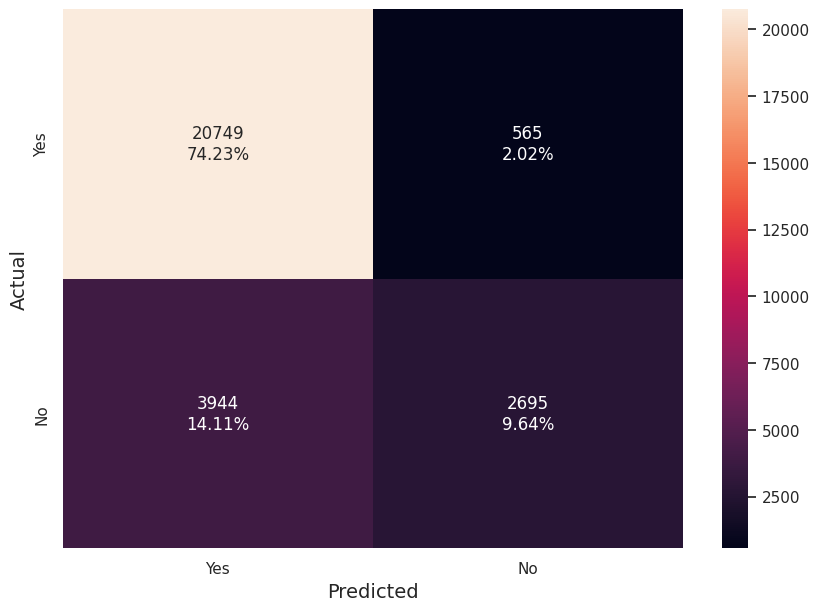

In [147]:
# Creating new pipeline with best parameters
bagg_tuned = make_pipeline(
    StandardScaler(),
    BaggingClassifier(
        max_features=0.9,
        max_samples=0.9,
        random_state=1,
        n_estimators=50,
        n_jobs=-1
    )
)

# Fit the model on training data
bagg_tuned.fit(X_train, y_train)

#Calculating different metrics
get_metrics_score(bagg_tuned)

#Creating confusion matrix
make_confusion_matrix(bagg_tuned, y_test)

## Decision Tree Classifier

## Hyperparameter Tuning using GridSearchCV


In [ ]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV
param_grid = {
    'decisiontreeclassifier__max_depth': np.arange(2, 30),
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 5, 7, 10],
    'decisiontreeclassifier__max_leaf_nodes' : [2, 3, 5, 10, 15],
    'decisiontreeclassifier__min_impurity_decrease': [0.0001,0.001,0.01,0.1]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs=-1)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(f"Best parameters are {grid_cv.best_params_} \nScore={grid_cv.best_score_}:")

Metric,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
Score,0.805,0.805,0.203,0.197,0.901,0.913,0.331,0.325


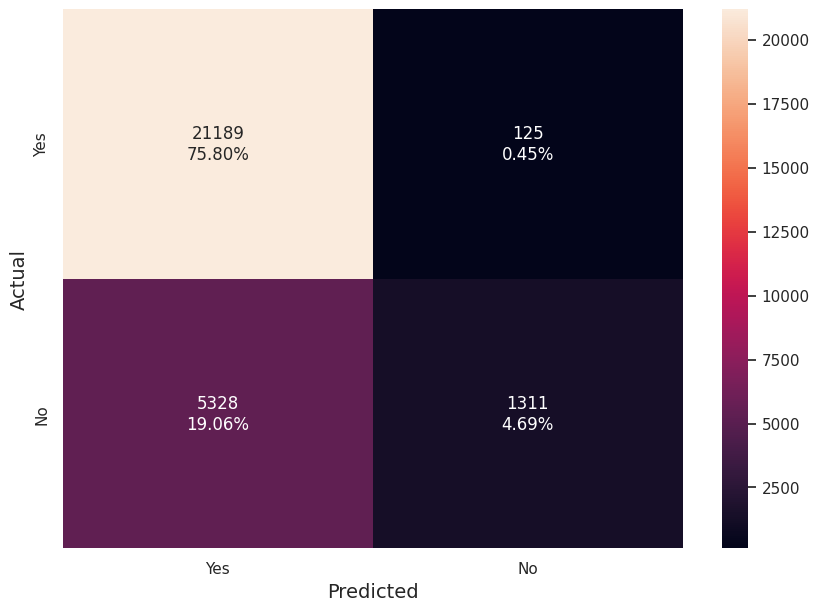

In [148]:
# Creating new pipeline with best parameters
dtree_tuned = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(
        max_depth=7,
        max_leaf_nodes=15,
        random_state=1,
        min_impurity_decrease=0.0001,
        min_samples_leaf=1,
    )
)

# Fit the model on training data
dtree_tuned.fit(X_train, y_train)

#Calculating different metrics
get_metrics_score(dtree_tuned)

#Creating confusion matrix
make_confusion_matrix(dtree_tuned, y_test)

## Stacking Classifier

In [ ]:
estimators = [('Bagging Classifier', bagg_tuned), ('Decision Tree', dtree_tuned)]
stacking_classifier= StackingClassifier(estimators=estimators, final_estimator=xgb_tuned)
stacking_classifier.fit(X_train, y_train)

#Calculating different metrics
get_metrics_score(stacking_classifier)

#Creating confusion matrix
make_confusion_matrix(stacking_classifier, y_test)

* I will use xgb_tuned model to predict the test set output variables

## Test Set Prediction

In [149]:
test = pd.read_csv('/content/Test_set..csv')
test.columns

FileNotFoundError: [Errno 2] No such file or directory: 'Test_set.csv'

In [ ]:
test_id = test.ID
test_id.head()

In [ ]:
test.annual_income.fillna(test.annual_income.mean(), inplace=True)
test.last_week_pay.fillna(test.last_week_pay.mean(), inplace=True)
test.total_current_balance.fillna(test.total_current_balance.mean(), inplace=True)
test.total_revolving_limit.fillna(test.total_revolving_limit.mean(), inplace=True)
test.total_acc.fillna(test.total_acc.mean(), inplace=True)

In [ ]:
job_experience = {'<5 Years':0, '6-10 years':1, '10+ years':2}
test['job_experience'] = test['job_experience'].map(job_experience).astype('Int32')

loan_term = {'3 years': 0, '5 years': 1}
test['loan_term'] = test['loan_term'].map(loan_term).astype('Int32')

loan_grade = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
test['loan_grade'] = test['loan_grade'].map(loan_grade).astype('Int32')

loan_subgrade = {'A1':0,  'A2':1,  'A3':2,  'A4':3,  'A5':4,
                 'B1':5,  'B2':6,  'B3':7,  'B4':8,  'B5':9,
                 'C1':10, 'C2':11, 'C3':12, 'C4':13, 'C5':14,
                 'D1':15, 'D2':16, 'D3':17, 'D4':18, 'D5':19,
                 'E1':20, 'E2':21, 'E3':22, 'E4':23, 'E5':24,
                 'F1':25, 'F2':26, 'F3':27, 'F4':28, 'F5':29,
                 'G1':30, 'G2':31, 'G3':32, 'G4':33, 'G5':34}
test['loan_subgrade'] = test['loan_subgrade'].map(loan_subgrade).astype('Int32')

home_ownership = {'MORTGAGE':0, 'RENT':1, 'OWN':2, 'OTHER':3, 'NONE':4}
test['home_ownership'] = test['home_ownership'].map(home_ownership).astype('Int32')

income_verification_status = {'Verified':0, 'Not Verified':1, 'Source Verified':2}
test['income_verification_status'] = test['income_verification_status'].map(income_verification_status).astype('Int32')

loan_purpose = {'debt_consolidation': 0, 'credit_card':1, 'home_improvement': 2, 'other': 3}
test['loan_purpose'] = test['loan_purpose'].map(loan_purpose).astype('Int32')

application_type = {'INDIVIDUAL': 0, 'JOINT':1}
test['application_type'] = test['application_type'].map(application_type).astype('Int32')

state_code = {'AK':0,  'AL':1,  'AR':2,  'AZ':3,  'CA':4 , 'CO':5,  'CT':6,  'DC':7,  'DE':8,
              'FL':9,  'GA':10, 'HI':11, 'IA':12, 'ID':13, 'IL':14, 'IN':15, 'KS':16, 'KY':17,
              'LA':18, 'MA':19, 'MD':20, 'ME':21, 'MI':22, 'MN':23, 'MO':24, 'MS':25, 'MT':26,
              'NC':27, 'ND':28, 'NE':29, 'NH':30, 'NJ':31, 'NM':32, 'NV':33, 'NY':34, 'OH':35,
              'OK':36, 'OR':37, 'PA':38, 'RI':39, 'SC':40, 'SD':41, 'TN':42, 'TX':43, 'UT':44,
              'VA':45, 'VT':46, 'WA':47, 'WI':48, 'WV':49, 'WY':50}
test['state_code'] = test['state_code'].map(state_code).astype('Int32')

In [ ]:
imputer = KNNImputer(n_neighbors=5)

In [ ]:
try:
    test.drop(['ID'], axis=1, inplace=True)
except:
    print('Already dropped')

In [ ]:
print(test.columns)
test.shape

In [ ]:
test = pd.DataFrame(imputer.fit_transform(test), columns=test.columns)
test.head()

In [ ]:
#Checking that no column has missing values in train or test sets
print(test.isna().sum())

In [ ]:
## Function to inverse the encoding
def test_inverse_mapping(x, y):
    inv_dict = {v: k for k, v in x.items()}
    test[y] = np.round(test[y]).map(inv_dict).astype('category')

In [ ]:
test_inverse_mapping(job_experience,'job_experience')
test_inverse_mapping(loan_term,'loan_term')
test_inverse_mapping(loan_grade,'loan_grade')
#inverse_mapping(loan_subgrade,'loan_subgrade')
test_inverse_mapping(home_ownership,'home_ownership')
test_inverse_mapping(income_verification_status,'income_verification_status')
test_inverse_mapping(loan_purpose,'loan_purpose')
test_inverse_mapping(application_type,'application_type')
#inverse_mapping(state_code,'state_code')

In [ ]:
test.head()

In [ ]:
cols = test.select_dtypes(include=['object','category'])
for i in cols.columns:
    print(test[i].value_counts(dropna=False))
    print('*'*30)

In [ ]:
test = pd.get_dummies(test, drop_first=True)
test.shape

In [ ]:
test.columns

In [ ]:
pred = xgb_tuned.predict(test)
print(f"Prediction has length: {len(pred)}")

In [ ]:
rediction_dict = {
    'ID': test_id,
    'default': pred
}
submit_df = pd.DataFrame(prediction_dict)
submit_df.head()

In [ ]:
submit_df.to_csv('Cardinal_submission.csv', index=False)

In [123]:
inverse_mapping(job_experience,'job_experience')
inverse_mapping(loan_term,'loan_term')
inverse_mapping(loan_grade,'loan_grade')
#inverse_mapping(loan_subgrade,'loan_subgrade')
inverse_mapping(home_ownership,'home_ownership')
inverse_mapping(income_verification_status,'income_verification_status')
inverse_mapping(loan_purpose,'loan_purpose')
inverse_mapping(application_type,'application_type')
#inverse_mapping(state_code,'state_code')

In [112]:
na_cols = df.columns[df.isna().all()]
num_na_cols = len(na_cols)
print(f"Number of columns with only NA values: {num_na_cols}")

Number of columns with only NA values: 0


In [113]:
to_drop = ["Score_Source_1", "Social_Circle_Default", "Own_House_Age"]
to_drop_2 = ["Client_Occupation", "Score_Source_3"]

In [114]:
df.head()

,ID,NaN
0,Job experience,3429
1,Interest_received,1
2,Application_Type,1
3,Last_week_pay,1380
4,Total_current_balance,5360


In [115]:
replace_with_mean = ["Child_Count", "Client_Family_Members", "Cleint_City_Rating",
                     "Application_Process_Day", "Application_Process_Hour", "Credit_Bureau"]

In [116]:
df.head()

,ID,NaN
0,Job experience,3429
1,Interest_received,1
2,Application_Type,1
3,Last_week_pay,1380
4,Total_current_balance,5360


In [ ]:
def remove_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  df_out = df[(df[col] > lower_bound) & (df[col] < upper_bound)]
  return df_out

In [117]:
def remove_missing_values(df, col):
  df = df.dropna(subset=[col])
  return df

In [118]:
def replace_missing_with_mean(df, col):
  df[col] = df[col].fillna(df[col].mean())
  return df

## The process of cleaning the data-
 - First remove the outliers
 - Fill the NA values with mean wherever possible

 - Remove all missing value columns then.

In [ ]:
for col in replace_with_mean:
  # df = remove_outliers(df, col)
  df = replace_missing_with_mean(df, col)

In [ ]:

df.shape


In [ ]:
for col in df.columns:
  df = remove_missing_values(df, col)

In [ ]:
df.isna().sum()

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df["Default"].value_counts()

In [ ]:
df.isna().sum()

In [ ]:
df.columns

In [ ]:
def balance_dataset(df, target_col):
  class_0 = df[df[target_col] == 0]
  class_1 = df[df[target_col] == 1]

  sample_size = min(len(class_0), len(class_1))

  balanced_df = pd.concat([class_0.sample(sample_size), class_1.sample(sample_size)])

  return balanced_df.sample(frac=1)

df_train = balance_dataset(df, 'Default')

In [ ]:
df_train.shape

In [ ]:
df_train["Default"].value_counts()

Pipeline to the model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with one-hot encoding
def random_forest_pipeline(df, target_column, categorical_columns):
    # Step 1: Data preparation
    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(), categorical_columns),
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])
        ]
    )

    # Step 4: Define Random Forest pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    rf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = rf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        return rf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return rf_pipeline, predict_new_data

# Example usage of the function
# df = pd.read_csv('your_data.csv')  # Load your dataset
# categorical_columns = ['col1', 'col2']  # Specify your categorical columns
# rf_model, predict_new_data = random_forest_pipeline(df, 'target', categorical_columns)  # Replace 'target' with your actual target column

# Making predictions on new data
# new_data = pd.DataFrame(...)  # Load or create new data to predict on
# predictions = predict_new_data(new_data)
# print(predictions)



In [ ]:


import numpy as np
cat_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
print(cat_cols)


# Random Forest Pipeline
 - Only for Random Forest classifier model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with type consistency and one-hot encoding
def random_forest_pipeline_2(df, target_column, categorical_columns):
    # Step 1: Data preparation
    # Ensure that all categorical columns have consistent string data types
    for col in categorical_columns:
        df[col] = df[col].astype(str)

    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),  # One-hot encoding for categorical columns
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])  # Scaling numerical columns
        ]
    )

    # Step 4: Define Random Forest pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    rf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = rf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        # Convert categorical columns to strings before prediction
        for col in categorical_columns:
            new_data[col] = new_data[col].astype(str)
        return rf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return rf_pipeline, predict_new_data, y_pred

# Example usage of the function
# df = pd.read_csv('your_data.csv')  # Load your dataset
# categorical_columns = ['col1', 'col2']  # Specify your categorical columns
# rf_model, predict_new_data = random_forest_pipeline(df, 'target', categorical_columns)  # Replace 'target' with your actual target column

# Making predictions on new data
# new_data = pd.DataFrame(...)  # Load or create new data to predict on
# predictions = predict_new_data(new_data)
# print(predictions)


# Classsification Pipeline
- Trying 3 different models to choose best model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with type consistency, one-hot encoding, and multiple model options
def classification_pipeline(df, target_column, categorical_columns, model):
    # Step 1: Data preparation
    # Ensure that all categorical columns have consistent string data types
    for col in categorical_columns:
        df[col] = df[col].astype(str)

    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),  # One-hot encoding for categorical columns
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])  # Scaling numerical columns
        ]
    )

    # Step 4: Define the classification pipeline with the selected model
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(clf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    clf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = clf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        # Convert categorical columns to strings before prediction
        for col in categorical_columns:
            new_data[col] = new_data[col].astype(str)
        return clf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return clf_pipeline, predict_new_data, y_pred, y_test



In [ ]:
# Using RandomForest
rf_model, predict_new_data_rf, rf_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, RandomForestClassifier(random_state=42))


In [ ]:
# Using Logistic Regression
lr_model, predict_new_data_lr, lr_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, LogisticRegression(max_iter=1000))

In [ ]:
# Using Gradient Boosting
gb_model, predict_new_data_gb, gb_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, GradientBoostingClassifier(random_state=42))

In [ ]:

def evaluate_model(model, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [ ]:
def compare_models(y_test, gb_predictions, lr_predictions, rf_predictions):
  models = [gb_model, lr_model, rf_model]
  predictions = [gb_predictions, lr_predictions, rf_predictions]
  accuracies = []

  for model, pred in zip(models, predictions):
    accuracies.append(evaluate_model(model, y_test, pred))
    return accuracies

In [ ]:
# Plotting the accuracies
accuracies = compare_models(y_test, gb_predictions, lr_predictions, rf_predictions)
models = ['Gradient Boosting', 'Logistic Regression', 'Random Forest']
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracies Comparison Before Tuning')
plt.show()

In [ ]:
X = df_train.drop(columns=['Default'])
y = df_train['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Tuning rf forest classifier

from sklearn.model_selection import GridSearchCV

def tune_random_forest(X_train, y_train):
    # Define the parameter grid for grid search
    param_grid = {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__max_depth': [None, 20, 30],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__bootstrap': [True, False]
    }


    rf = rf_model
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Random Forest:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_


In [ ]:
# For logistics Regression



def tune_logistic_regression(X_train, y_train):
    param_grid = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'classifier__penalty': ['l2'],
        'classifier__max_iter': [200, 500]
    }
    lr = lr_model
    grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Logistic Regression:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_


In [ ]:
# For GradientBoostingClassifier

def tune_gradient_boosting(X_train, y_train):
    param_grid = {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__learning_rate': [0.1, 0.05],
        'classifier__max_depth': [5, 8],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__subsample': [1.0]
    }
    gb = gb_model
    grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Gradient Boosting:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_


## From Rf classifier
Best parameters for Random Forest: {'classifier__bootstrap': True, 'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best cross-validation accuracy: 0.6575842696629214

## From lr classifier
Best parameters for Logistic Regression: {'classifier__C': 0.1, 'classifier__max_iter': 200, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best cross-validation accuracy: 0.6394535240040857


## From Gradint Booster
Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Best cross-validation accuracy: 0.628140960163432



## Uncomment these lines when you need to tune the model as its time taking

In [ ]:
# tune_random_forest(X_train, y_train)

In [ ]:
# tune_logistic_regression(X_train, y_train)

In [ ]:
# tune_gradient_boosting(X_train, y_train)

# Comparison of accuracies after tuning the models
- It's decreased actually

In [ ]:
best_cv_accuracy = [0.628140960163432, 0.6394535240040857, 0.6575842696629214]

plt.figure(figsize=(10, 6))
plt.bar(models, best_cv_accuracy, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison Of Best Cross Validation Accuracies')
plt.show()


# Put Best params model in classification pipeline to get report over it


In [ ]:

rf_tuned_model, predict_new_data_rf_tuned, rf_predictions_tuned, y_test = classification_pipeline(df_train, 'Default', cat_cols, RandomForestClassifier(random_state=42,
                                                                                                                                                        n_estimators=100,
                                                                                                                                                        max_depth= 30,
                                                                                                                                                        min_samples_leaf= 1,
                                                                                                                                                        min_samples_split=5))

In [ ]:
gb_tuned_model, predict_new_data_gb_tuned, gb_predictions_tuned, y_test = classification_pipeline(df_train,
                                                                                                  'Default',
                                                                                                  cat_cols,
                                                                                                  GradientBoostingClassifier(random_state=42,
                                                                                                                                     n_estimators=300,
                                                                                                                                     learning_rate=0.1,
                                                                                                                                     max_depth=5,
                                                                                                                                     min_samples_leaf=2))


In [ ]:
lr_tuned_model, predict_new_data_lr_tuned, lr_predictions_tuned, y_test = classification_pipeline(df_train,
                                                                                                  'Default',
                                                                                                  cat_cols,
                                                                                                  LogisticRegression(max_iter=1000,
                                                                                                                     C=0.1,
                                                                                                                     penalty='l2',
                                                                                                                     solver='liblinear'))

In [ ]:
test_accuracies = []
tuned_models = [gb_tuned_model, lr_tuned_model, rf_tuned_model]
tuned_predictions = [gb_predictions_tuned, lr_predictions_tuned, rf_predictions_tuned]

for model, pred in zip(tuned_models, tuned_predictions):
  test_accuracies.append(evaluate_model(model, y_test, pred))



In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracies Comparison Before Tuning')

plt.subplot(1,2,2)
plt.bar(models, test_accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracies Comparison After Tuning')



# Saving The Model

In [ ]:
# import pickle

# def save_model(model, filename):
#   with open(filename, 'wb') as file:
#     pickle.dump(model, file)

In [ ]:
# save_model(model, 'model.pkl')

In [ ]:
# import pandas as pd

# def save_predictions_to_csv(predictions, filename):
#   df = pd.DataFrame({'Predictions': predictions}, index=range(len(predictions)))
#   df.to_csv(filename, index=False)

In [ ]:
# save_predictions_to_csv(predictions, 'predictions.csv')

In [ ]:
# save_predictions_to_csv_2(test_ds, 'test.csv')

In [ ]:
# test_ds = df_train.drop(columns=['Default'])

In [ ]:
# test_ds.to_csv('test_update.csv', index=False)